

# **TFG DE ANALYTICS**

### Cargar librerias y Datos

In [62]:
# LIBRERÍAS BÁSICAS
import sys
import pathlib
import warnings
import collections
import collections.abc
import numpy as np
import pandas as pd
import six

# Oculta avisos para que la salida sea más limpia
warnings.filterwarnings("ignore")

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display

# TABLAS
from tabulate import tabulate

# MODELADO Y PREPROCESAMIENTO
import lightgbm as lgb
import shap
from sklearn.base import clone
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA


# CLUSTERING Y REDUCCIÓN DE DIMENSIONALIDAD
import umap
import umap.umap_ as umap_
from sklearn.cluster import DBSCAN
from yellowbrick.cluster import KElbowVisualizer


# MÉTRICAS
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    davies_bouldin_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score
)


# INSTALAR SKOPERULES
!pip install skope-rules six


# COMPATIBILIDAD PARA SKOPERULES
# Compatibilidad con versiones nuevas de Python
collections.Iterable = collections.abc.Iterable

# Compatibilidad con versiones nuevas de sklearn
import sklearn
sklearn.externals.six = six
sys.modules["sklearn.externals.six"] = six

# Compatibilidad con versiones nuevas de NumPy
np.int = int
np.float = float
np.bool = bool

# Parche para versiones nuevas de sklearn:
# SkopeRules usa base_estimator, pero sklearn moderno usa estimator
skope_file = pathlib.Path(
    "/usr/local/lib/python3.12/dist-packages/skrules/skope_rules.py")

if skope_file.exists():
    text = skope_file.read_text()
    text = text.replace("base_estimator=", "estimator=")
    skope_file.write_text(text)

# Limpiamos módulos ya cargados para que se importe la versión parcheada
for module_name in list(sys.modules):
    if module_name.startswith("skrules"):
        del sys.modules[module_name]

# IMPORTAR SKOPERULES
from skrules import SkopeRules
print("SkopeRules importado y parcheado correctamente.")

SkopeRules importado y parcheado correctamente.


In [63]:
# Carga el archivo de datos en una tabla llamada df.
df = pd.read_csv('german_credit_data.csv')
# Muestra las primeras filas para comprobar que los datos se cargaron bien.
print(df.head())

# Guarda el número total de registros del dataset.
num_filas = df.shape[0]
# Imprime el número de observaciones disponibles.
print(f"El número de observaciones es: {num_filas}")

   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  Risk  
0           1169         6             radio/TV  good  
1           5951        48             radio/TV   bad  
2           2096        12            education  good  
3           7882        42  furniture/equipment  good  
4           4870        24                  car   bad  
El número de observaciones es: 1000


### Limpieza de los datos

*   Missing Values

In [64]:
# Calcula el porcentaje de valores faltantes por columna (incluye todas las columnas)
missing_percentage = df.isnull().mean() * 100

# Muestra el porcentaje de valores faltantes por columna, incluyendo las que no tienen valores faltantes
print(missing_percentage)

Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64


Se elimina la variable Checkin Account debido a la cantidad de valores faltantes. Se considero un umbral del 30%.

En compensación para la variable Saving Accounts se creó una categoria independiente llamada "Missings" permitiendo preservar la información implícita asociada a la ausencia del dato y facilitando su análisis exploratorio posterior.

In [65]:
# Mantengo la variable saving_accounts tratando los valores faltantes como una categoria independiente
df["Saving accounts"] = df["Saving accounts"].fillna("Missing")

# Borrar aquellas columnas que seran utiles en mi dataset
df=df.drop(columns=['Unnamed: 0',"Checking account"],axis=1)

In [66]:
# Vuelve a mostrar el dataset tras la limpieza inicial.
df.head()

,Age,Sex,Job,Housing,Saving accounts,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,Missing,1169,6,radio/TV,good
1,22,female,2,own,little,5951,48,radio/TV,bad
2,49,male,1,own,little,2096,12,education,good
3,45,male,2,free,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,4870,24,car,bad


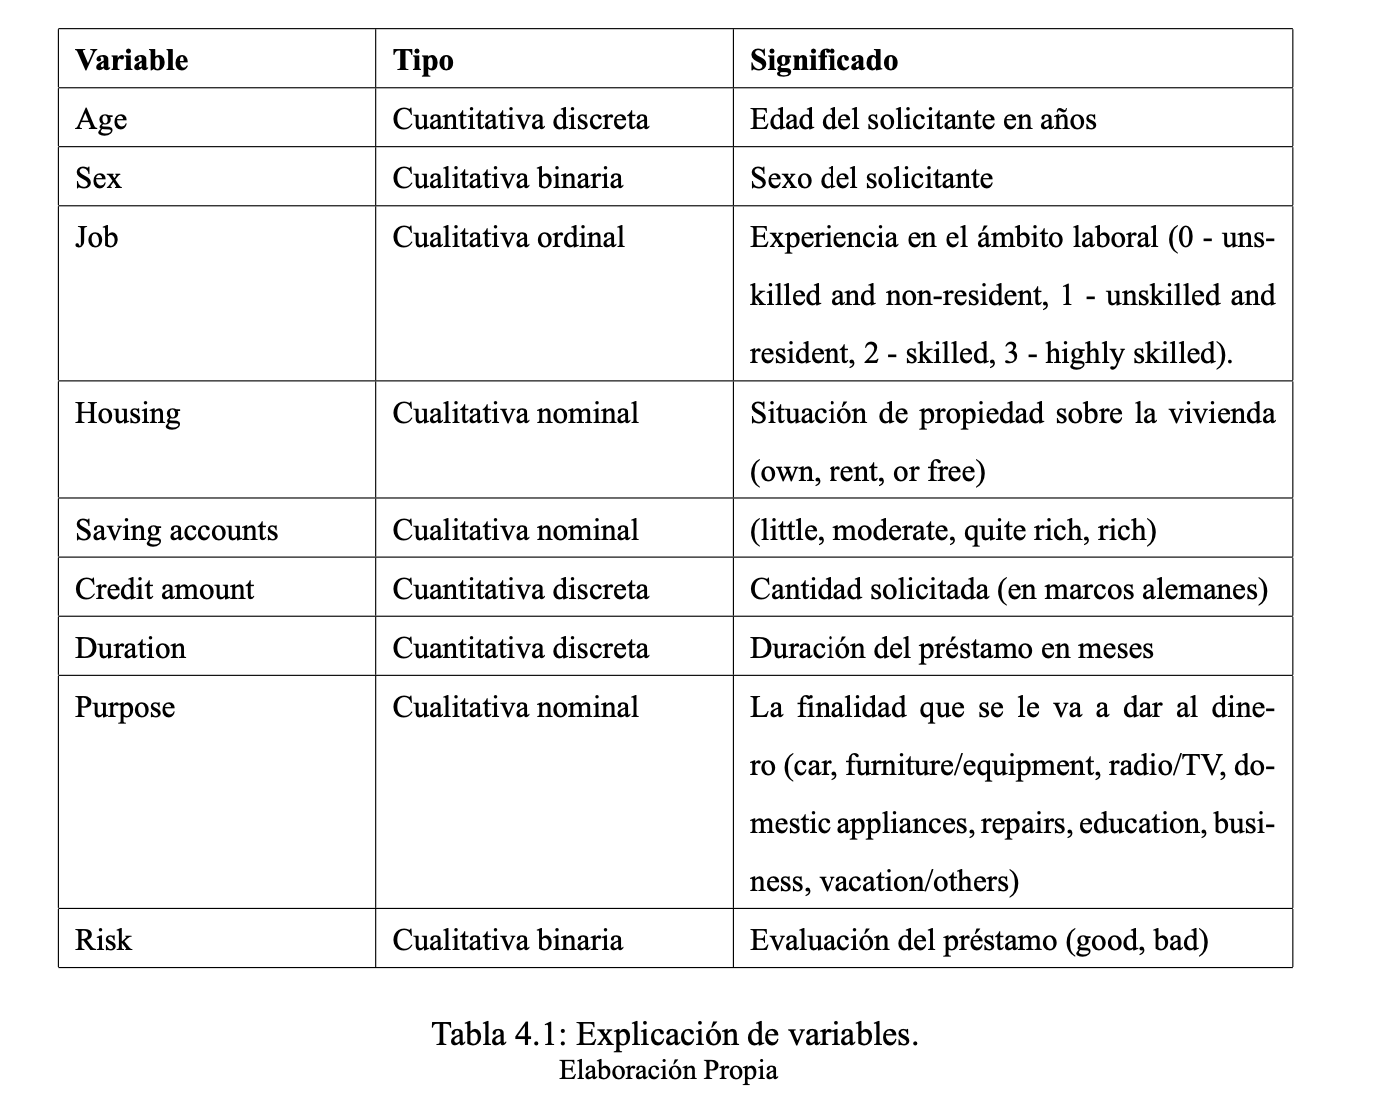

*   One-Hot encoding de variables categóricas nominales (se excluye la variable target)

In [67]:
# Define cuál es la variable objetivo que queremos predecir.
target = 'Risk'

# Identifica las variables categóricas del dataset.
categorical_columns = list(df.select_dtypes(include=['object']).columns)
# Quita la variable objetivo de la lista de variables explicativas.
categorical_columns.remove(target)


# Convierte variables categóricas en columnas numéricas 0/1.
df_corr = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True)

# Para observar si los cambios estan correctos y ver como quedaria el "dataset" llamo al df_corr
# Muestra el dataset ya preparado con variables dummy.
df_corr

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,good,True,True,False,False,False,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,bad,False,True,False,True,False,False,False,False,False,False,False,True,False,False
2,49,1,2096,12,good,True,True,False,True,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,good,True,False,False,True,False,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,bad,True,False,False,True,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,good,False,True,False,True,False,False,False,False,False,False,True,False,False,False
996,40,3,3857,30,good,True,True,False,True,False,False,False,True,False,False,False,False,False,False
997,38,2,804,12,good,True,True,False,True,False,False,False,False,False,False,False,True,False,False
998,23,2,1845,45,bad,True,False,False,True,False,False,False,False,False,False,False,True,False,False


*   Estudio de los percentiles para identificación de Outliers

In [68]:
# Selecciona las variables numéricas principales.
numeric_cols = ['Age', 'Credit amount', 'Duration']

# Calcula estadísticos y percentiles para detectar valores extremos.
percentile_table = df[numeric_cols].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).T

# Reordena la tabla para quedarse con los estadísticos más importantes.
percentile_table = percentile_table[
    ['mean', 'min', '25%', '50%', '75%', '95%', '99%', 'max']
]

# Muestra la tabla de percentiles.
percentile_table

,mean,min,25%,50%,75%,95%,99%,max
Age,35.546,19.0,27.0,33.0,42.00,60.0,67.01,75.0
Credit amount,3271.258,250.0,1365.5,2319.5,3972.25,9162.7,14180.39,18424.0
Duration,20.903,4.0,12.0,18.0,24.00,48.0,60.00,72.0


El análisis de los percentiles elevados (95 y 99), junto con la inspección visual mediante histogramas, pone de manifiesto la presencia de distribuciones asimétricas, especialmente en el importe del crédito. No obstante, los valores situados por encima del percentil 99 corresponden a observaciones plausibles dentro del contexto crediticio y no a errores de registro. Asimismo, el percentil 99 se encuentra relativamente próximo al valor máximo en las variables analizadas, lo que indica una transición progresiva hacia los valores extremos. En consecuencia, se opta por no eliminar observaciones, preservando la variabilidad natural del conjunto de datos.

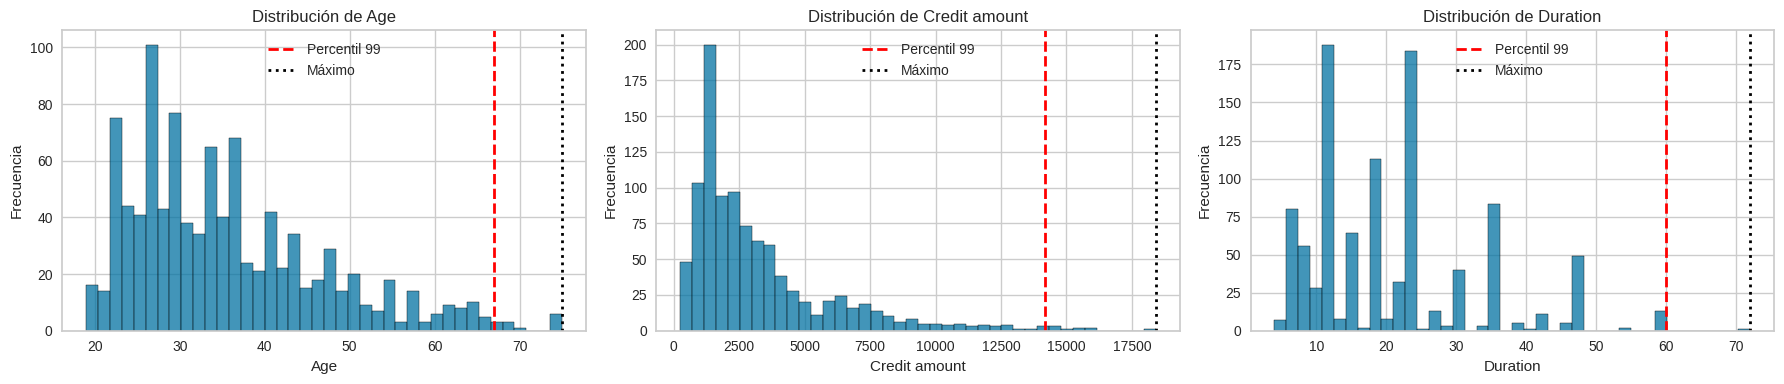

In [69]:
#Esto es solo para verlo visualmente los percentiles
# Cuenta cuántas variables se van a representar.
n_cols = len(numeric_cols)

# Crea una figura con varios gráficos en la misma fila o cuadrícula.
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4), sharey=False)

# Repite el mismo análisis para cada variable de la lista.
for ax, col in zip(axes, numeric_cols):
    p99 = df[col].quantile(0.99)
    max_val = df[col].max()

    # Dibuja un histograma para ver la distribución de la variable.
    sns.histplot(df[col], bins=40, kde=False, ax=ax)

    ax.axvline(p99, color='red', linestyle='--', linewidth=2, label='Percentil 99')
    ax.axvline(max_val, color='black', linestyle=':', linewidth=2, label='Máximo')

    # Añade el título del gráfico.
    ax.set_title(f'Distribución de {col}')
    # Añade el nombre del eje X.
    ax.set_xlabel(col)
    # Añade el nombre del eje Y.
    ax.set_ylabel('Frecuencia')
    # Añade la leyenda para interpretar colores o grupos.
    ax.legend()

# Ajusta los espacios para que los gráficos no se solapen.
plt.tight_layout()
# Muestra el gráfico en pantalla.
plt.show()

# **1) ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA)**

### **Análisis de variables numéricas**

* ### Boxplot

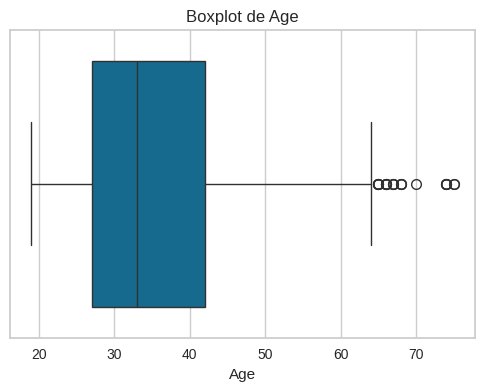

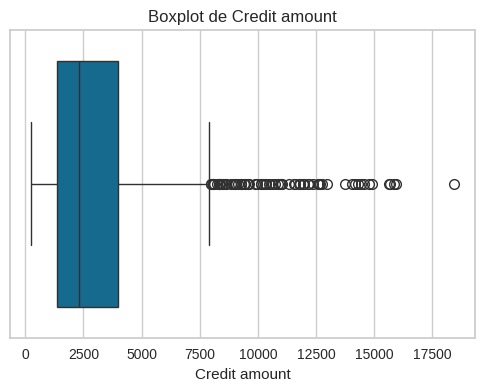

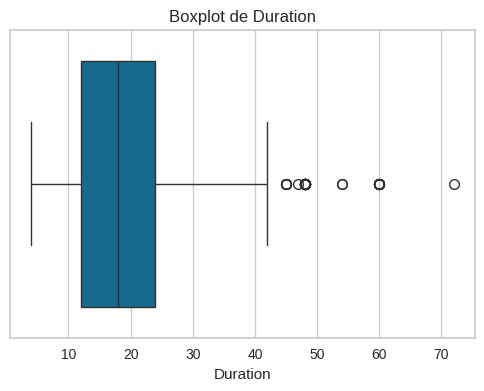

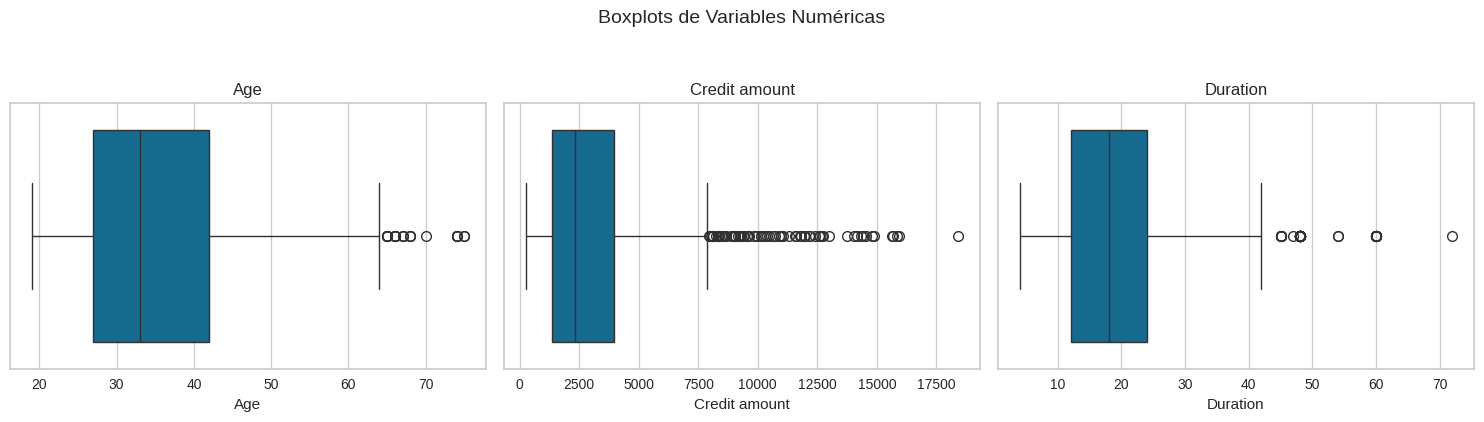

In [70]:
# Repite el mismo análisis para cada variable de la lista.
for col in numeric_cols:
    # Crea una nueva figura para el gráfico.
    plt.figure(figsize=(6,4))
    # Dibuja un boxplot para ver dispersión y posibles outliers.
    sns.boxplot(x=df[col])
    # Añade el título del gráfico.
    plt.title(f'Boxplot de {col}')
    # Muestra el gráfico en pantalla.
    plt.show()

# Cuenta cuántas variables se van a representar.
n_cols = len(numeric_cols)

# Crea una figura con varios gráficos en la misma fila o cuadrícula.
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=False)

# Asegura que el código funcione aunque solo haya una variable.
if n_cols == 1:
    axes = [axes]

# Repite el mismo análisis para cada variable de la lista.
for ax, col in zip(axes, numeric_cols):
    # Dibuja un boxplot para ver dispersión y posibles outliers.
    sns.boxplot(x=df[col], ax=ax)
    # Añade el título del gráfico.
    ax.set_title(col)
    # Añade el nombre del eje X.
    ax.set_xlabel(col)

fig.suptitle('Boxplots de Variables Numéricas', fontsize=14, y=1.05)
# Ajusta los espacios para que los gráficos no se solapen.
plt.tight_layout()
# Muestra el gráfico en pantalla.
plt.show()

* ### Histograma

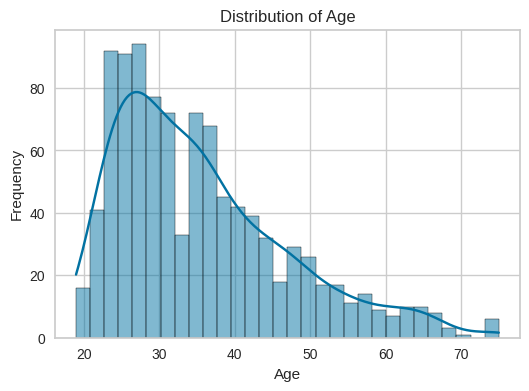

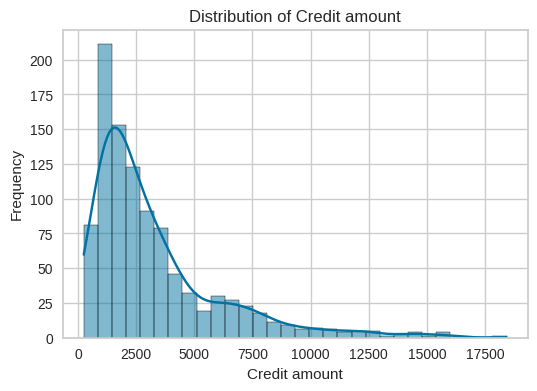

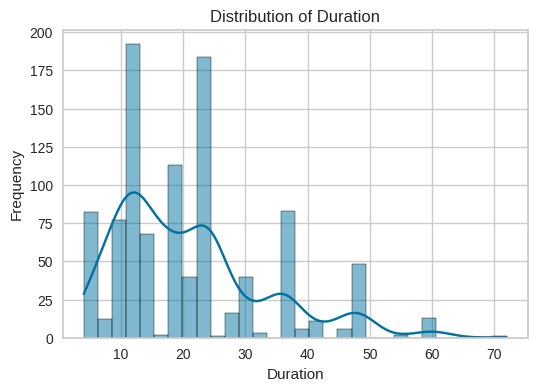

In [71]:
# Repite el mismo análisis para cada variable de la lista.
for col in numeric_cols:
    # Crea una nueva figura para el gráfico.
    plt.figure(figsize=(6,4))
    # Dibuja un histograma para ver la distribución de la variable.
    sns.histplot(df[col], bins=30, kde=True)
    # Añade el título del gráfico.
    plt.title(f'Distribution of {col}')
    # Añade el nombre del eje X.
    plt.xlabel(col)
    # Añade el nombre del eje Y.
    plt.ylabel('Frequency')
    # Muestra el gráfico en pantalla.
    plt.show()

### **Análisis de variables categóricas**

* ### Análisis univariante de la variable TARGET (y)

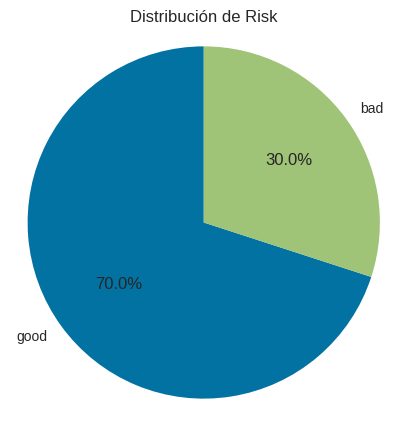

In [72]:
df['Risk'].value_counts()

risk_counts = df[target].value_counts()

# Crea una nueva figura para el gráfico.
plt.figure(figsize=(5,5))
# Dibuja un gráfico circular con la proporción de cada grupo.
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

# Añade el título del gráfico.
plt.title('Distribución de Risk')
plt.axis('equal')  # Para que sea un círculo perfecto
# Muestra el gráfico en pantalla.
plt.show()

* ### Countplots

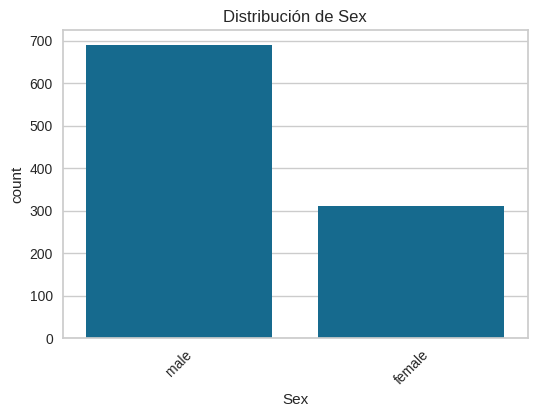

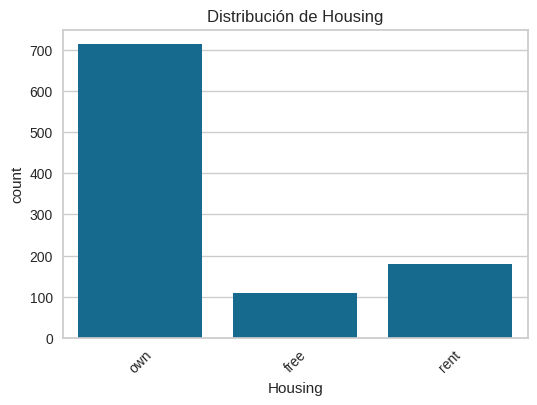

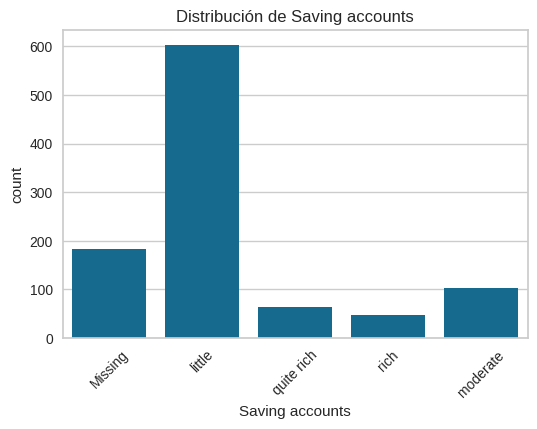

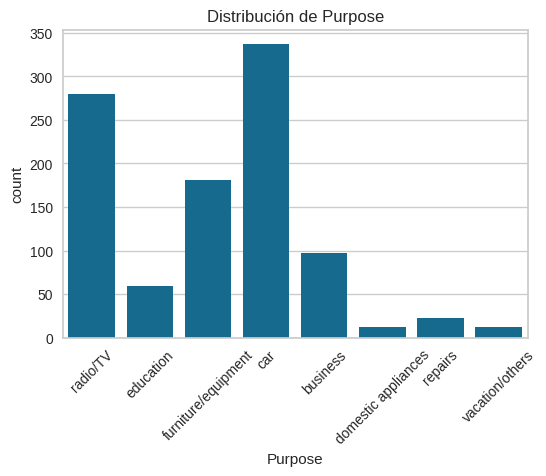

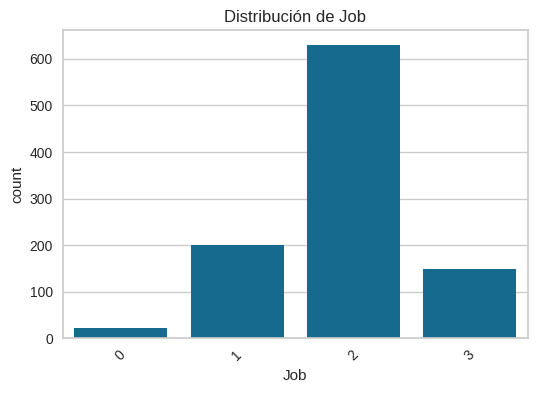

In [73]:
categorical_columns.append('Job') # es una variable categórica ordinal

# Repite el mismo análisis para cada variable de la lista.
for col in categorical_columns:
    # Crea una nueva figura para el gráfico.
    plt.figure(figsize=(6,4))
    # Dibuja un gráfico de barras con el número de casos por categoría.
    sns.countplot(x=col, data=df)
    # Añade el título del gráfico.
    plt.title(f'Distribución de {col}')
    # Ajusta las etiquetas del eje X para que se lean mejor.
    plt.xticks(rotation=45)
    # Muestra el gráfico en pantalla.
    plt.show()

* ### Gráficos normalizados

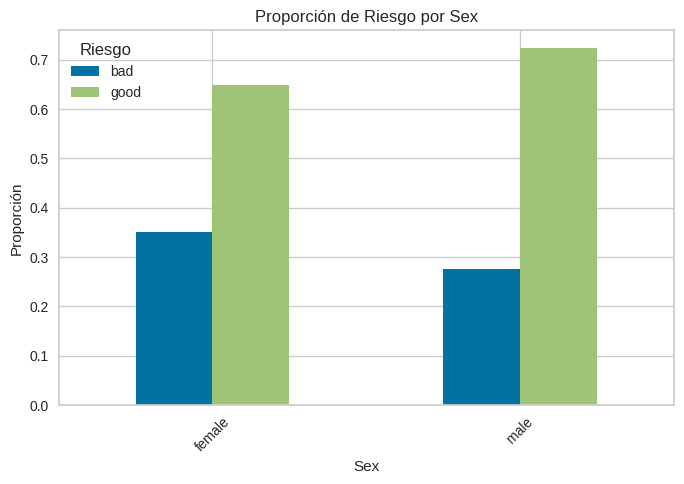

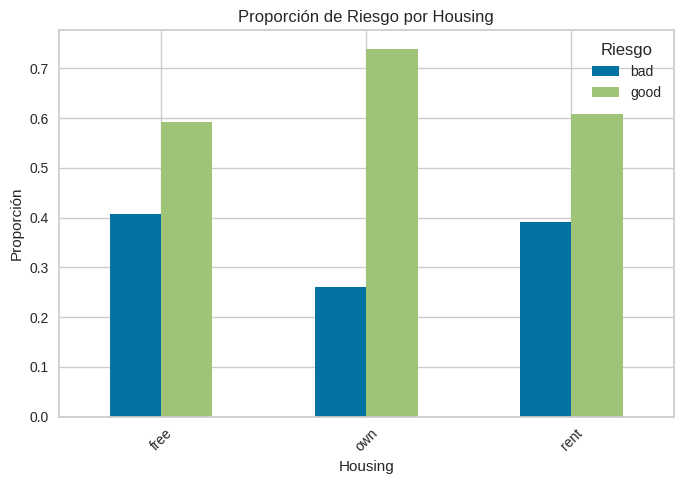

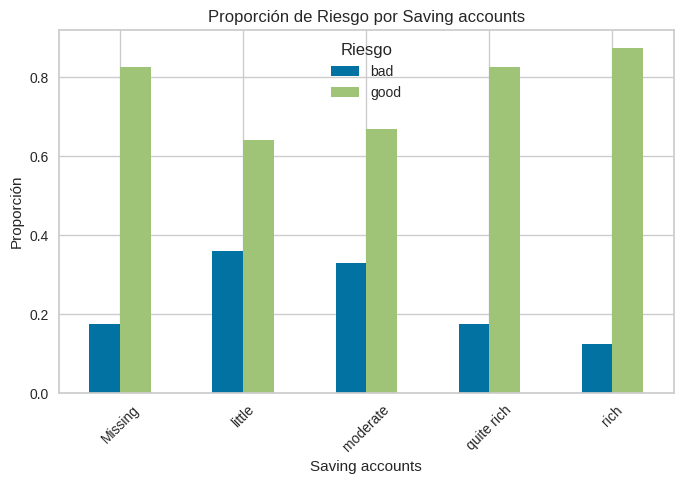

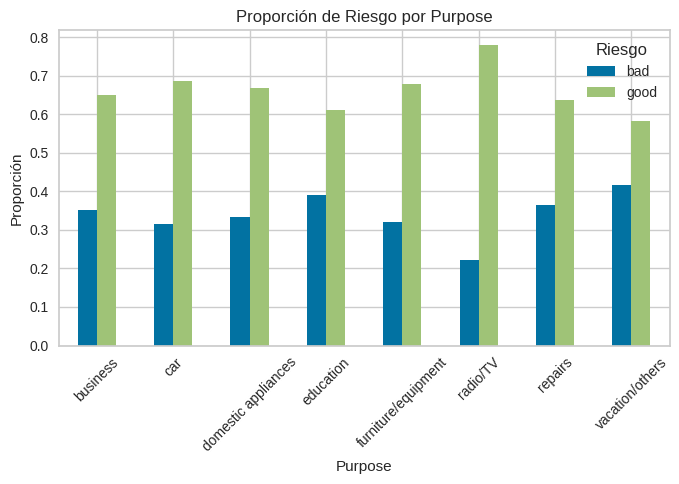

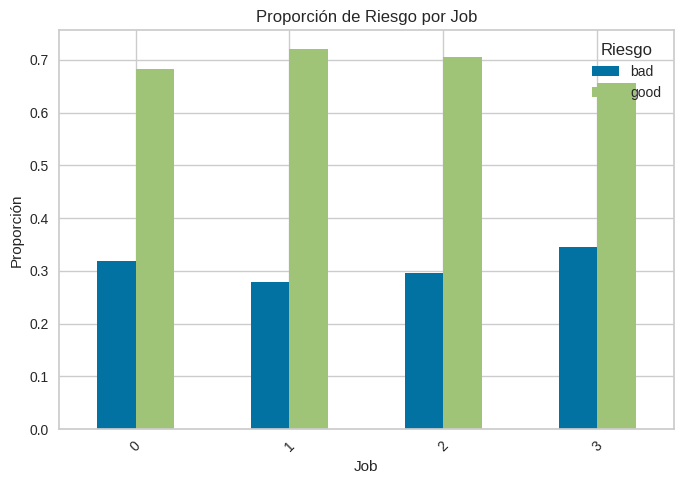

In [74]:
# Repite el mismo análisis para cada variable de la lista.
for col in categorical_columns:
    prop_table = pd.crosstab(
        df[col],
        df[target],
        normalize='index'
    )

    prop_table.plot(
        kind='bar',
        figsize=(7,5)
    )

    # Añade el título del gráfico.
    plt.title(f'Proporción de Riesgo por {col}')
    # Añade el nombre del eje Y.
    plt.ylabel('Proporción')
    # Añade el nombre del eje X.
    plt.xlabel(col)
    # Añade la leyenda para interpretar colores o grupos.
    plt.legend(title='Riesgo')
    # Ajusta las etiquetas del eje X para que se lean mejor.
    plt.xticks(rotation=45)
    # Ajusta los espacios para que los gráficos no se solapen.
    plt.tight_layout()
    # Muestra el gráfico en pantalla.
    plt.show()

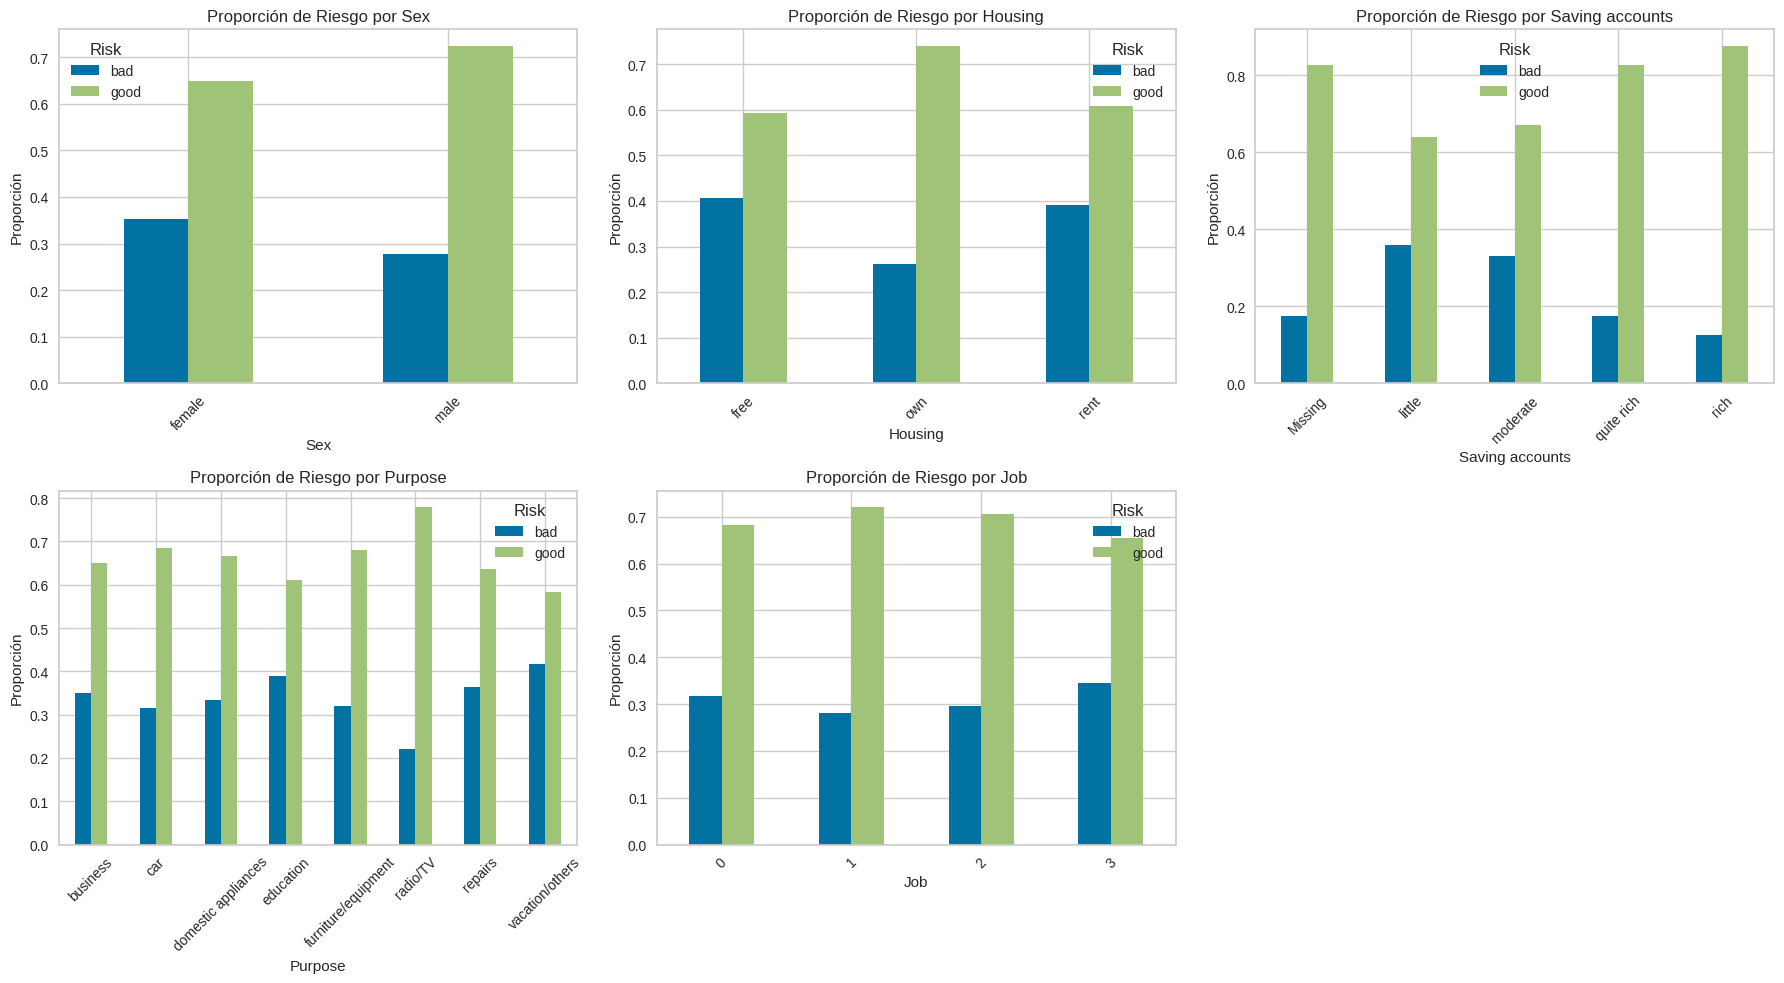

In [75]:
n_vars = len(categorical_columns)

# Crea una figura con varios gráficos en la misma fila o cuadrícula.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Repite el mismo análisis para cada variable de la lista.
for i, col in enumerate(categorical_columns):
    prop_table = pd.crosstab(
        df[col],
        df[target],
        normalize='index'
    )

    prop_table.plot(
        kind='bar',
        ax=axes[i]
    )

    # Añade el título del gráfico.
    axes[i].set_title(f'Proporción de Riesgo por {col}')
    # Añade el nombre del eje Y.
    axes[i].set_ylabel('Proporción')
    # Añade el nombre del eje X.
    axes[i].set_xlabel(col)
    # Ajusta las etiquetas del eje X para que se lean mejor.
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar ejes sobrantes (si hay menos de 6 gráficas)
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

# Ajusta los espacios para que los gráficos no se solapen.
plt.tight_layout()
# Muestra el gráfico en pantalla.
plt.show()


### **Matriz de correlación**

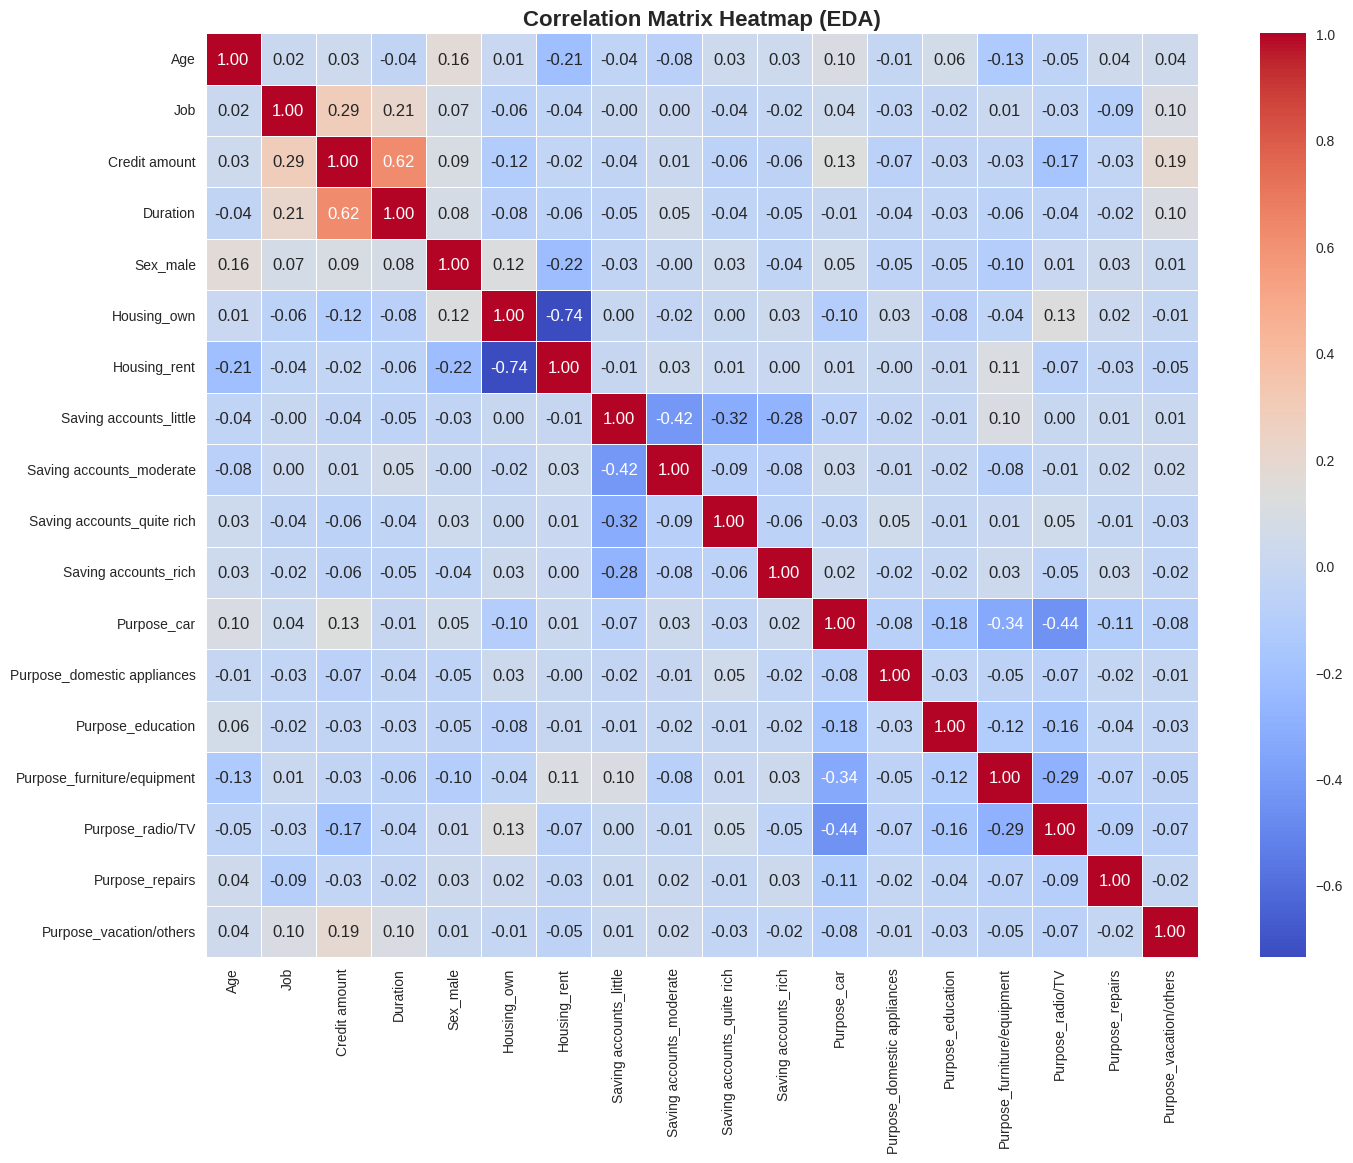

In [76]:
# Calcula la matriz de correlación entre variables.
corr_matrix = df_corr.drop(columns=[target]).corr()

# Crea una nueva figura para el gráfico.
plt.figure(figsize=(16, 12))
# Dibuja un mapa de calor para visualizar correlaciones.
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.5,
    cbar=True,
    annot=True,
    fmt=".2f"
)

# Añade el título del gráfico.
plt.title('Correlation Matrix Heatmap (EDA)', fontsize=16, fontweight='bold')
# Muestra el gráfico en pantalla.
plt.show()

# **2) LIGHTGBM**

**Objetivo:** El objetivo de esta fase es entrenar un modelo LightGBM que sirva como base para generar una representación explicativa de cada observación mediante valores SHAP.

In [77]:
# Separa las variables explicativas del modelo.
X = df_corr.drop(columns='Risk')
# Convierte la variable objetivo en 1 para bad y 0 para good.
y = df_corr['Risk'].map({'bad': 1, 'good': 0})

# Divide los datos en entrenamiento y test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Crea el modelo LightGBM de clasificación binaria.
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    random_state=42
)

# Define los hiperparámetros que se van a probar.
param_dist = {
    'n_estimators': [200, 400, 600, 800, 1000, 1500], #numero de arboles que construye el modelo
    'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1], # la velocidad en que el modelo aprende EN CADA ARBÓL
    'max_depth': [2, 3, 4, 5, 6, 7, -1], # Profundidad máxima a la que puede llegar el arbol
    'num_leaves': [15, 20, 31, 50, 70, 100], #numero de hojas finales máximo que tiene cada árbol (donde el ábol llega al fin)
    'min_child_samples': [5, 10, 20, 30, 50] # controla que las decisiones del árbol no se basen en grupos demasiado pequeños de datos.
}

# Configura la búsqueda automática de mejores parámetros.
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,#es la lista de hiperparámetros y valores posibles que quieres probar.
    n_iter=100, # prueba 100 combinaciones aleatorias de hiperparámetros. No prueba todas, solo 100.
    scoring='roc_auc', # evalúa cada combinación usando el AUC, que mide qué tan bien separa el modelo entre good y bad.
    cv=5,#Usa validación cruzada con 5 partes. Divide el entrenamiento en 5 bloques y va probando el modelo varias veces.
    random_state=42, #Hace que los resultados sean reproducibles. Si ejecutas otra vez el código, probará las mismas combinaciones.
    n_jobs=-1, # Se entrenan 5 x 100 = 500 modelos, asi que esto me ayuda a que vaya mas rapido.
    verbose=1 #Muestra mensajes durante el entrenamiento para ver el progreso.
)

# Entrena varios modelos y elige la mejor combinación.
random_search.fit(X_train, y_train)

# Guarda el mejor modelo encontrado.
best_model = random_search.best_estimator_
# Muestra los parámetros óptimos del modelo.
print("Mejores parámetros:", random_search.best_params_)

# Predicción:

# Genera las predicciones de clase del modelo.
y_pred = best_model.predict(X_test)
# Calcula las probabilidades estimadas por el modelo.
y_proba = best_model.predict_proba(X_test)

# Calcula el porcentaje de aciertos del modelo.
acc = accuracy_score(y_test, y_pred)
# Calcula la capacidad del modelo para separar good y bad.
auc = roc_auc_score(y_test, y_proba[:, 1])

# Imprime la accuracy del modelo.
print(f"Accuracy (umbral 0.5): {acc:.3f}")
# Imprime el AUC del modelo en test.
print(f"ROC AUC (test): {auc:.3f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 240, number of negative: 560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 350
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

* ### Matriz de Confusión

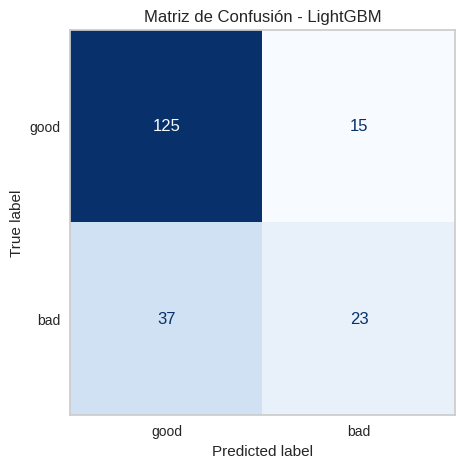

In [78]:
# Predicciones con umbral estándar 0.5
y_pred = best_model.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# Prepara la matriz de confusión para dibujarla
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["good", "bad"]
)

# Plot limpio
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.grid(False)
plt.title("Matriz de Confusión - LightGBM")
plt.show()

| Métrica | Valor | Interpretación                                               |
| ------- | ----: | ------------------------------------------------------------ |
| **TN**  |   125 | Clientes realmente `good` que el modelo predice como `good`. |
| **FP**  |    15 | Clientes realmente `good` que el modelo predice como `bad`.  |
| **FN**  |    37 | Clientes realmente `bad` que el modelo predice como `good`.  |
| **TP**  |    23 | Clientes realmente `bad` que el modelo predice como `bad`.   |


**ACCURACY:**

Accuracy = (TN + TP) / Total

Accuracy = (125 + 23) / 200 = 0.740

**REGLA DE LA MAYORIA:**

* good = 125 + 15 = 140 casos
* bad = 37 + 23 = 60 casos
* total = 200 casos

Regla de la mayoría = 140 / 200 = 0.700

**COMPARACIÓN:**
* Accuracy modelo = 74.0%
* Regla de mayoría = 70.0%


**Explicación:** La matriz de confusión muestra que el modelo clasifica correctamente 125 clientes good y 23 clientes bad, mientras que comete 15 falsos positivos y 37 falsos negativos. La accuracy obtenida con el umbral estándar de 0.5 es de 0.740, lo que significa que el modelo clasifica correctamente el **74.0%** de los casos del conjunto test. Para interpretar este resultado, se compara con la regla de la mayoría. En el conjunto test, la clase mayoritaria es good, con 140 observaciones de un total de 200, por lo que una clasificación basada únicamente en la clase mayoritaria obtendría una accuracy del **70.0%**. **Por tanto, el modelo mejora esta línea base en 4 puntos porcentuales.**

  ------------------


**SENSIBILIDAD:**

Sensitivity = TP / (TP + FN)

Sensitivity = 23 / (23 + 37) = 23 / 60 = 0.383

**ESPECIFICIDAD:**

Specificity = TN / (TN + FP)

Specificity = 125 / (125 + 15) = 125 / 140 = 0.893


**Explicación:** Al analizar las métricas por clase, se observa que la especificidad es elevada, con un valor de 0.893, lo que indica que el modelo identifica correctamente la mayoría de los clientes good. Sin embargo, la sensitividad es de **0.383,** por lo que el modelo solo detecta correctamente el 38.3% de los clientes bad. Esto muestra que el modelo tiene más dificultad para identificar la clase positiva (Bad = 1).

-----------------

**PRECISIÓN:**

Explica de los casos que el modelo predijo como bad, cuántos realmente eran bad.

Precision = TP / (TP + FP)

Precision = 23 / (23 + 15) = 23 / 38 = 0.605

**Explicación:** La precision es aproximadamente 60.5%. Esto significa que, cuando el modelo predice que un cliente es bad, acierta el 60.5% de las veces.

* ### Curva ROC

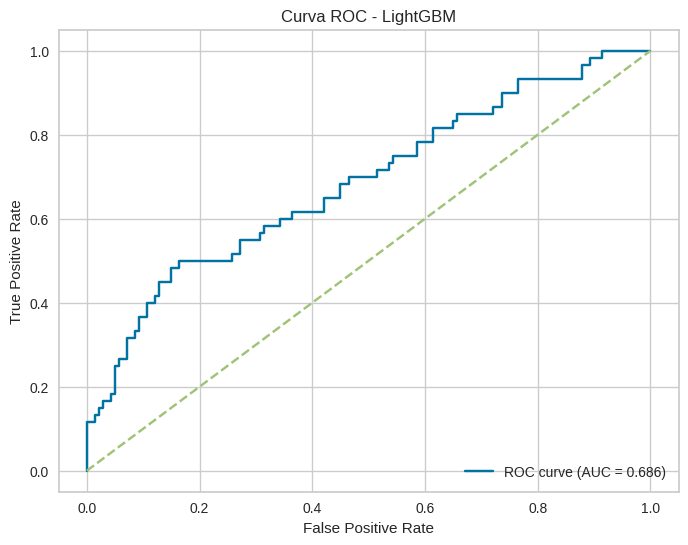

In [79]:
# Probabilidades de la clase positiva ("bad" = 1)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Calcula los puntos necesarios para la curva ROC.
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# Calcula la capacidad del modelo para separar good y bad.
auc = roc_auc_score(y_test, y_proba)

# Crea una nueva figura para el gráfico.
plt.figure(figsize=(8, 6))
# Dibuja una línea en el gráfico.
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
# Dibuja una línea en el gráfico.
plt.plot([0, 1], [0, 1], linestyle="--")
# Añade el nombre del eje X.
plt.xlabel("False Positive Rate")
# Añade el nombre del eje Y.
plt.ylabel("True Positive Rate")
# Añade el título del gráfico.
plt.title("Curva ROC - LightGBM")
# Añade la leyenda para interpretar colores o grupos.
plt.legend(loc="lower right")
plt.grid(True)
# Muestra el gráfico en pantalla.
plt.show()

Finalmente, el **ROC AUC** en test es de **0.686**, lo que indica una capacidad razonable para separar ambas clases. Por tanto, el modelo es útil como base para el análisis posterior con SHAP, UMAP y DBSCAN, pero sus resultados deben interpretarse con cautela, especialmente en la detección de clientes de mayor riesgo.


# **3) SHAP**

**Objetivo:** El objetivo de esta fase es calcular los valores SHAP para cuantificar la contribución de cada variable a la predicción de cada observación y construir el espacio explicativo utilizado en las etapas posteriores de segmentación.

In [80]:
# Entrenamos el modelo final sobre todo el dataset
clustering_model = clone(best_model)# crea un modelo nuevo con los mejores hiperparámetros
clustering_model.fit(X, y) # lo entrena desde cero con todo X, y

# Calculamos los valores SHAP sobre todo X
explainer = shap.TreeExplainer(clustering_model) #Creamos un explicador SHAP específico para el modelo LightGBM ya entrenado.
shap_values = explainer.shap_values(X) # Calculamos, para cada persona/fila de X, cuánto aporta cada variable a la predicción del modelo.

# Nos quedamos con los SHAP de la clase positiva: bad = 1
# Lo que quiere decir es que si SHAP me da valores separados por clase,
# me quedo con la clase bad; si ya me los da directamente, los uso tal cual
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 300, number of negative: 700
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 1000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

* Gráfico de importancia media absoluta SHAP

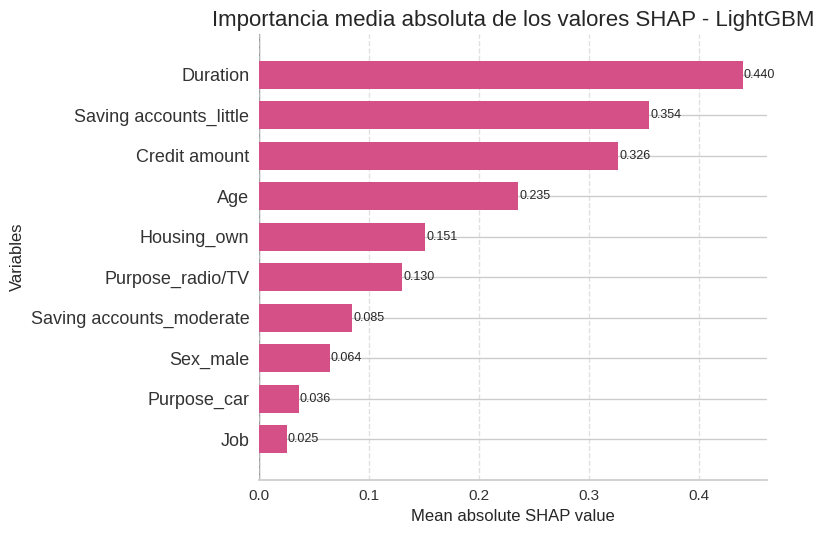

In [81]:
# Crea un gráfico de barras con las 10 variables más importantes según SHAP.
# La importancia se calcula como el valor medio absoluto de SHAP.
# En este caso, se interpreta la clase positiva del modelo: bad = 1.
shap.summary_plot(
    shap_vals,          # Valores SHAP calculados para cada observación y variable
    X,                  # Dataset original con los nombres de las variables
    plot_type="bar",    # Indica que queremos un gráfico de barras
    show=False,         # Evita que el gráfico se muestre automáticamente para poder editarlo
    max_display=10,     # Muestra solo las 10 variables más importantes
    color="#d45087"     # Define el color de las barras
)

# Recupera la figura y los ejes actuales creados por SHAP
fig, ax = plt.gcf(), plt.gca()

# Recorre cada barra del gráfico para añadir su valor numérico
for bar in ax.patches:
    # Obtiene la longitud de la barra, que corresponde al valor SHAP medio absoluto
    width = bar.get_width()

    # Escribe el valor numérico al final de cada barra
    ax.text(
        width + 0.001,                      # Posición horizontal del texto
        bar.get_y() + bar.get_height() / 2, # Posición vertical centrada en la barra
        f'{width:.3f}',                     # Valor mostrado con tres decimales
        va='center',                        # Centra verticalmente el texto
        fontsize=9                          # Tamaño de la fuente
    )

# Añade el título del gráfico
ax.set_title(
    "Importancia media absoluta de los valores SHAP - LightGBM",
    fontsize=16
)

# Añade la etiqueta del eje X
ax.set_xlabel(
    "Mean absolute SHAP value",
    fontsize=12
)

# Añade la etiqueta del eje Y
ax.set_ylabel(
    "Variables",
    fontsize=12
)

# Añade una cuadrícula vertical para facilitar la lectura de los valores
ax.grid(axis="x", linestyle="--", alpha=0.6)

# Ajusta automáticamente los márgenes para que no se corten textos ni etiquetas
plt.tight_layout()

# Muestra el gráfico final
plt.show()

* Distribución de valores originales y SHAP por variable

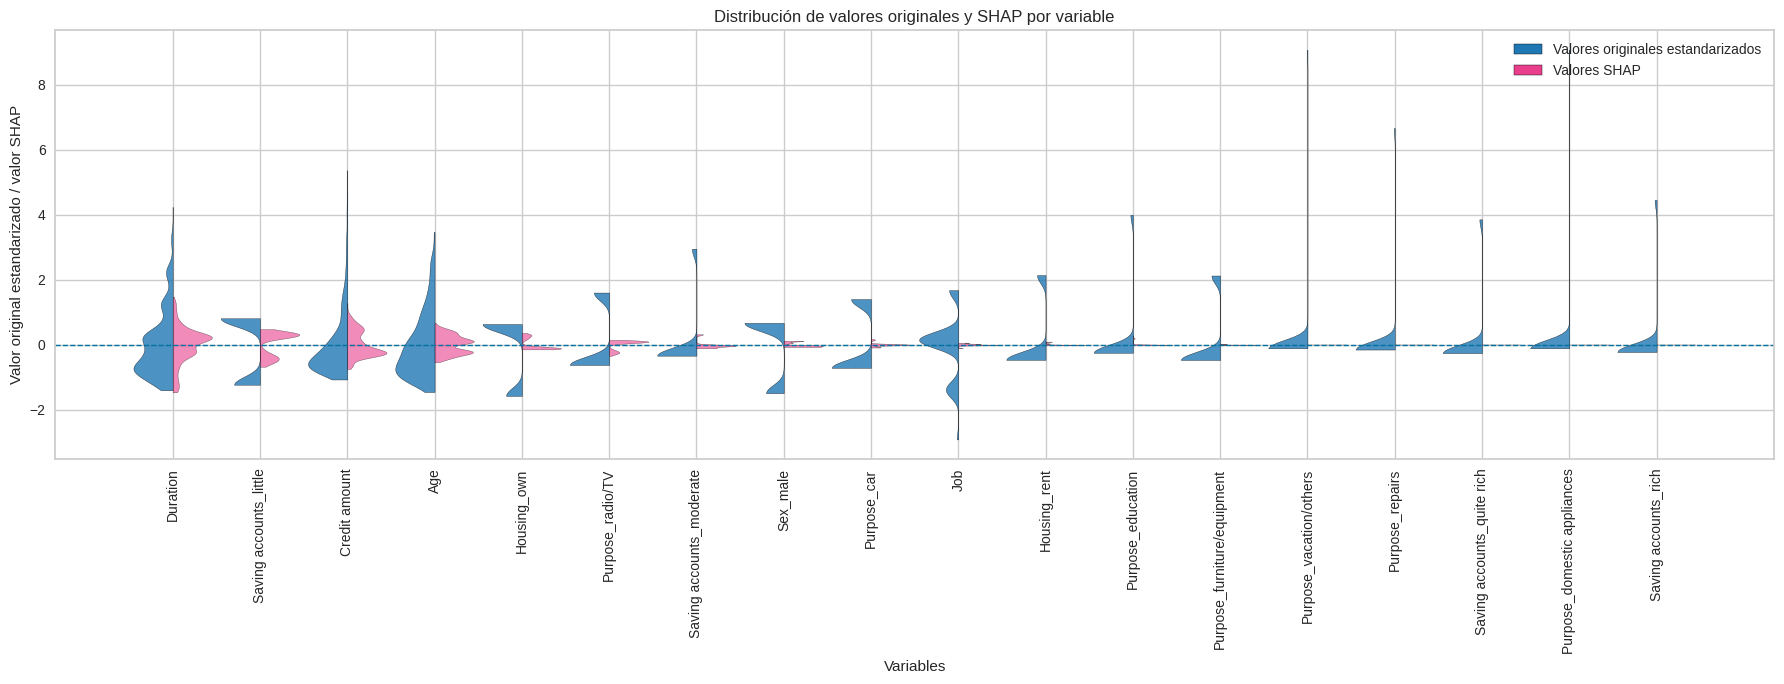

In [82]:
# Convierte shap_vals a matriz numérica si viene como objeto Explanation
shap_vals_array = shap_vals.values if hasattr(shap_vals, "values") else shap_vals

# Si SHAP devuelve valores por clase, nos quedamos con la clase positiva: bad = 1
if len(shap_vals_array.shape) == 3:
    shap_vals_array = shap_vals_array[:, :, 1]

# Calcula la importancia media absoluta de cada variable según SHAP
mean_abs_shap_values = np.abs(shap_vals_array).mean(axis=0)

# Estandariza las variables originales para compararlas visualmente con SHAP
X_scaled = (X - X.mean()) / X.std(ddof=0).replace(0, 1)

# Guarda los nombres de las variables del modelo
feature_names = X.columns.tolist()

# Ordena TODAS las variables de mayor a menor importancia SHAP
order = np.argsort(mean_abs_shap_values)[::-1]

# Guarda los nombres de todas las variables en ese orden
ordered_features = [feature_names[i] for i in order]

# Datos para los violines
raw_data = [X_scaled.iloc[:, i].dropna().values for i in order]
shap_data = [shap_vals_array[:, i] for i in order]

# Función para mostrar medio violín
def clip_violin_half(body, center, side='left'):
    path = body.get_paths()[0]
    verts = path.vertices

    if side == 'left':
        verts[:, 0] = np.minimum(verts[:, 0], center)
    elif side == 'right':
        verts[:, 0] = np.maximum(verts[:, 0], center)
    else:
        raise ValueError("side debe ser 'left' o 'right'")

# Violines raw vs SHAP
fig, ax = plt.subplots(figsize=(18, 7))
positions = np.arange(len(order))

vp_raw = ax.violinplot(
    raw_data,
    positions=positions,
    widths=0.9,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for i, body in enumerate(vp_raw['bodies']):
    body.set_facecolor('#1f77b4')
    body.set_edgecolor('black')
    body.set_alpha(0.8)
    clip_violin_half(body, positions[i], side='left')

vp_shap = ax.violinplot(
    shap_data,
    positions=positions,
    widths=0.9,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for i, body in enumerate(vp_shap['bodies']):
    body.set_facecolor('#e83e8c')
    body.set_edgecolor('black')
    body.set_alpha(0.6)
    clip_violin_half(body, positions[i], side='right')

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xticks(positions)
ax.set_xticklabels(ordered_features, rotation=90, ha='center')
ax.set_ylabel('Valor original estandarizado / valor SHAP')
ax.set_xlabel('Variables')
ax.set_title('Distribución de valores originales y SHAP por variable')

legend_handles = [
    Patch(facecolor='#1f77b4', edgecolor='black', label='Valores originales estandarizados'),
    Patch(facecolor='#e83e8c', edgecolor='black', label='Valores SHAP')
]

ax.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

# **3) UMAP y DBSCAN**


**Objetivo:** Seleccinar hiperparámetros optimos mediante Grid Search para UMAP y DBSCAN. La selección de hiperparámetros se realizó de forma conjunta, evaluando para cada combinación de n_neighbors y min_dist las distintas configuraciones de eps y min_samples, con el objetivo de identificar la combinación global que generara agrupamientos más compactos, mejor separados y con menor porcentaje de ruido.

In [83]:
# Grid de UMAP
n_neighbors_grid = [30, 50, 75, 100, 150, 200] # controla el equilibrio entre estructura local y global.
min_dist_grid = [0, 0.01, 0.05, 0.1] #controla la compactación de los puntos en la proyección.

# Grid de DBSCAN
eps_grid = [0.5, 0.7, 0.9, 1.5, 2.0, 2.5] #radio utilizado para definir vecindades.
min_samples_grid = [10, 20, 30, 40, 45, 50] #número mínimo de observaciones para formar un cluster.


# Resultados

results = []

# Loop conjunto UMAP + DBSCAN
for n_neighbors in n_neighbors_grid:

    for min_dist in min_dist_grid:

        # 1. Crear embedding UMAP sobre valores SHAP
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=42
        )

        embedding = reducer.fit_transform(shap_vals) #Reduce los valores SHAP a dos dimensiones.

        # 2. Probar DBSCAN sobre ese embedding
        for eps in eps_grid:

            for min_samples in min_samples_grid:

                dbscan = DBSCAN(
                    eps=eps,
                    min_samples=min_samples
                )

                labels = dbscan.fit_predict(embedding)# Aplica DBSCAN sobre el embedding generado por UMAP.
                #El objetivo es identificar grupos de observaciones con patrones similares de contribución SHAP.

                # Número de clusters sin contar ruido
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

                # Porcentaje de ruido considerado por DBSCAN.
                noise_pct = (labels == -1).mean() * 100

                # Métricas solo si hay al menos 2 clusters válidos
                # Son métricas de calidad de los clusters obtenidos
                if n_clusters >= 2:

                    mask = labels != -1

                    try:
                        sil = silhouette_score(
                            embedding[mask],
                            labels[mask]
                        )

                        dbi = davies_bouldin_score(
                            embedding[mask],
                            labels[mask]
                        )

                    except:
                        sil = np.nan
                        dbi = np.nan

                else:
                    sil = np.nan
                    dbi = np.nan

                results.append({ # Almacenamiento de resultados
                    "n_neighbors": n_neighbors,
                    "min_dist": min_dist,
                    "eps": eps,
                    "min_samples": min_samples,#cuántos vecinos mínimos necesita un punto para ser considerado núcleo de un cluster.
                    "clusters": n_clusters,
                    "noise_pct": round(noise_pct, 2),
                    "silhouette": sil, # Mide si los clusters están bien separados. Cuanto más alto, mejor.
                    "davies_bouldin": dbi # Mide si los clusters son compactos y separados. Cuanto más bajo, mejor.
                })


# Tabla final con resultados interpretables
results = pd.DataFrame(results)

# Filtramos configuraciones útiles:
# Al menos 2 clusters
# Máximo 0% de ruido
results_filtrados = results[
    (results["clusters"] >= 2) &
    (results["noise_pct"] <= 0)
]

# Ordenamos los resultados filtrados
results_filtrados = results_filtrados.sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
)
#Esto significa:
#Primero busca la mayor Silhouette.
#Si hay empates o valores parecidos, prioriza el menor Davies-Bouldin.

print("Mejores configuraciones interpretables:")
display(results_filtrados.head(10))

# Guardo los mejores valores en variables individuales.
best_config = results_filtrados.iloc[0]
best_n_neighbors = int(best_config["n_neighbors"])
best_min_dist = float(best_config["min_dist"])
best_eps = float(best_config["eps"])
best_min_samples = int(best_config["min_samples"])

# Verificando que las variables salen bien.
print("Configuración final seleccionada:")
print(best_config)

Mejores configuraciones interpretables:


,n_neighbors,min_dist,eps,min_samples,clusters,noise_pct,silhouette,davies_bouldin
204,50,0.01,2.0,10,3,0.0,0.802061,0.307292
205,50,0.01,2.0,20,3,0.0,0.802061,0.307292
206,50,0.01,2.0,30,3,0.0,0.802061,0.307292
210,50,0.01,2.5,10,3,0.0,0.802061,0.307292
211,50,0.01,2.5,20,3,0.0,0.802061,0.307292
212,50,0.01,2.5,30,3,0.0,0.802061,0.307292
213,50,0.01,2.5,40,3,0.0,0.802061,0.307292
214,50,0.01,2.5,45,3,0.0,0.802061,0.307292
215,50,0.01,2.5,50,3,0.0,0.802061,0.307292
162,50,0.00,1.5,10,3,0.0,0.800178,0.314169


Configuración final seleccionada:
n_neighbors       50.000000
min_dist           0.010000
eps                2.000000
min_samples       10.000000
clusters           3.000000
noise_pct          0.000000
silhouette         0.802061
davies_bouldin     0.307292
Name: 204, dtype: float64


# **4) UMAP**

**Objetivo UMAP:** El objetivo de esta fase es obtener una representación bidimensional de los valores SHAP que preserve las similitudes entre observaciones y facilite la identificación posterior de clusters mediante DBSCAN.

* UMAP de los Valores SHAP y Originales

In [84]:
# UMAP sobre variables originales
# Copia de los datos
X_umap_input = X.copy()

# Escalar únicamente variables numéricas continuas para que ninguna domine por tener valores más grandes.
# Esto lo hago debido al uso de las variables originales, porque los valores SHAP no se escalan porque ya representan la contribución de cada variable
cols_numericas = [
    col for col in ['Age', 'Credit amount', 'Duration']
    if col in X_umap_input.columns
]
scaler = StandardScaler()
X_umap_input[cols_numericas] = scaler.fit_transform(X_umap_input[cols_numericas])


# Aplicación final de UMAP:

# 1. UMAP sobre valores originales
# UMAP -> usando la configuración ganadora
umap_raw = umap.UMAP(
    n_components=2,
    n_neighbors=best_n_neighbors,
    min_dist=best_min_dist,
    random_state=42
)

X_2d = umap_raw.fit_transform(X_umap_input) # Aquí reduzco las variables originales a dos dimensiones.


# 2. UMAP sobre valores SHAP
# UMAP -> usando la misma configuración anterior que es la ganadora
umap_shap = umap.UMAP(
    n_components=2,
    n_neighbors=best_n_neighbors,
    min_dist=best_min_dist,
    random_state=42
)

S_2d = umap_shap.fit_transform(shap_vals) # Aquí reduzco las variables shap a dos dimensiones.

* Visualización

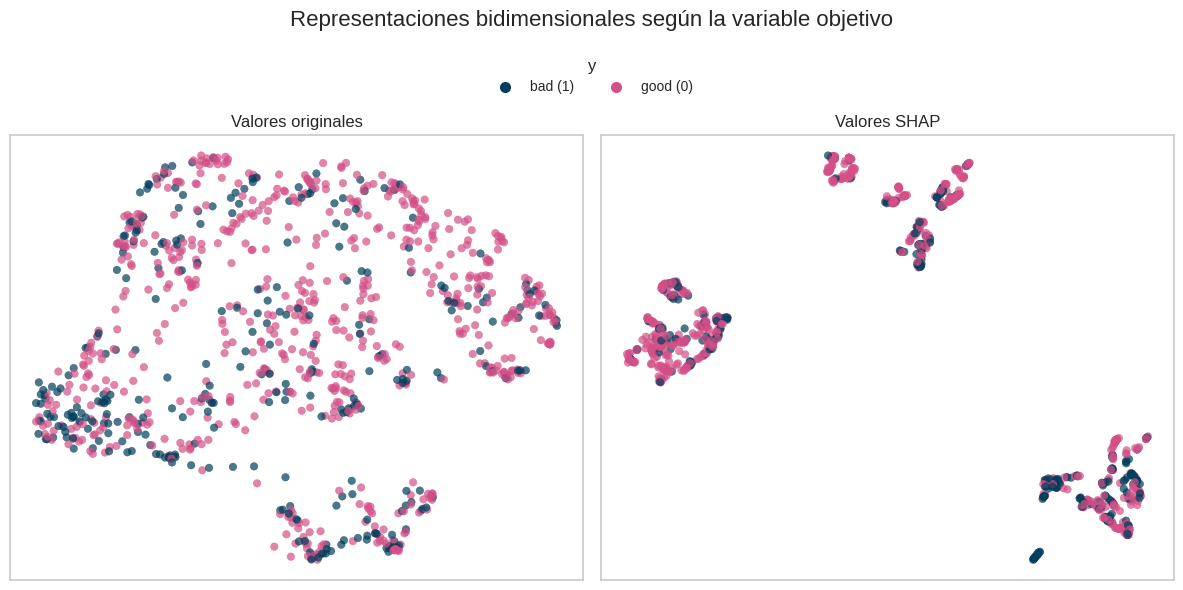

In [85]:
# Colores
y_plot = np.array(y)
colors = np.where(
    y_plot == 1,
    "#003f5c",  # bad = azul
    "#d45087"   # good = rosa
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Variables originales

axes[0].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=colors,
    alpha=0.7,
    s=30
)

axes[0].set_title("Valores originales")

# Valores SHAP

axes[1].scatter(
    S_2d[:, 0],
    S_2d[:, 1],
    c=colors,
    alpha=0.7,
    s=30
)

axes[1].set_title("Valores SHAP")

# Formato
for ax in axes:

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticks([])
    ax.set_yticks([])


# Leyenda
legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='bad (1)',
        markerfacecolor='#003f5c',
        markersize=8
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='good (0)',
        markerfacecolor='#d45087',
        markersize=8
    )
]

fig.legend(
    handles=legend_elements,
    title='y',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    frameon=False
)


# Título general
fig.suptitle(
    "Representaciones bidimensionales según la variable objetivo",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# **5) DBSCAN**


**Objetivo:**
El objetivo de esta fase es identificar grupos de observaciones con patrones explicativos similares a partir de la representación obtenida mediante UMAP.

* DBSCAN final sobre UMAP-SHAP

In [86]:
# Creamos el modelo final de DBSCAN usando los mejores hiperparámetros encontrados antes
dbscan_final = DBSCAN(
    eps= best_eps,                    # Radio máximo para considerar que dos puntos son vecinos
    min_samples=best_min_samples     # Número mínimo de puntos necesarios para formar una zona densa
)

# Aplicamos DBSCAN sobre la representación 2D de los valores SHAP
# El resultado es una etiqueta de cluster para cada observación
clusters = dbscan_final.fit_predict(S_2d)

* Gráfica de clusters con estilo del articulo

In [87]:
# Recorremos cada cluster para ver cuántas observaciones tiene y dónde está situado
for cluster, count in pd.Series(clusters).value_counts().sort_index().items():

    # Calculamos el centro medio del cluster en el espacio UMAP-SHAP
    centro = S_2d[clusters == cluster].mean(axis=0)

    # Mostramos el número del cluster, cuántas observaciones contiene y su centro
    print(cluster, count, centro)

0 315 [4.5554085 7.43645  ]
1 338 [11.904489 -2.098234]
2 347 [-4.0709896  3.0190015]


  Compruebo qué clase predomina realmente en cada cluster:

In [88]:
# Calculamos el porcentaje de good (0) y bad (1) dentro de cada cluster
cluster_summary = pd.crosstab(
    clusters,              # Etiquetas de cluster asignadas por DBSCAN
    y,                     # Variable objetivo: good (0) / bad (1)
    normalize="index"      # Calcula porcentajes por fila, es decir, dentro de cada cluster
) * 100                    # Lo pasamos a porcentaje

# Mostramos la tabla redondeada a 2 decimales
print(cluster_summary.round(2))

# Mostramos también los conteos reales de good (0) y bad (1) por cluster
pd.crosstab(clusters, y)

Risk       0      1
row_0              
0      79.68  20.32
1      53.55  46.45
2      77.23  22.77


Risk,0,1
row_0,,
0,251,64
1,181,157
2,268,79


* Gráfica

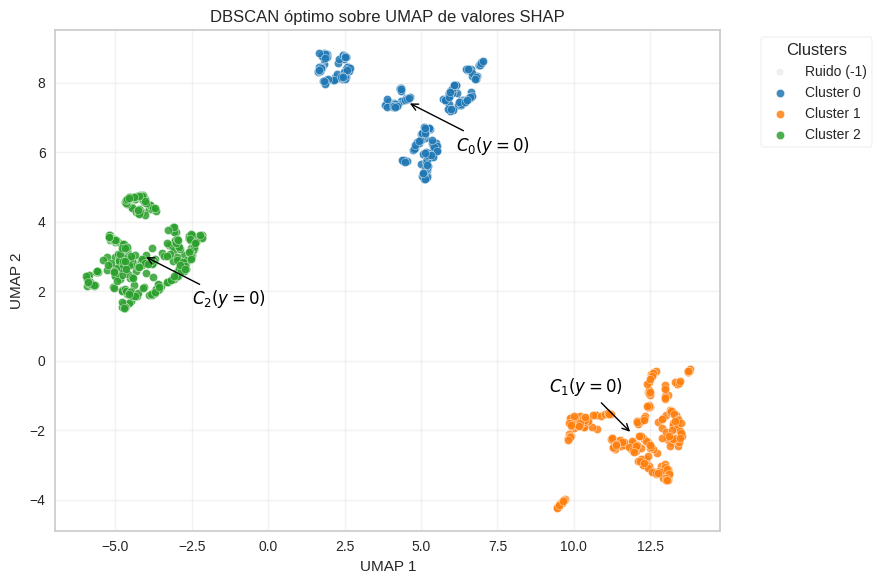

In [89]:
# Creamos un DataFrame para juntar las coordenadas UMAP, el cluster y el riesgo real
cluster_df = pd.DataFrame({
    "UMAP1": S_2d[:, 0],        # Primera dimensión de UMAP
    "UMAP2": S_2d[:, 1],        # Segunda dimensión de UMAP
    "Cluster": clusters,        # Cluster asignado por DBSCAN
    "Risk": np.array(y)         # Clase real: good (0) / bad (1)
})

# Creamos la figura
plt.figure(figsize=(9, 6))

# Seleccionamos las observaciones consideradas ruido por DBSCAN
noise_data = cluster_df[cluster_df["Cluster"] == -1]

# Dibujamos el ruido en gris claro
plt.scatter(
    noise_data["UMAP1"],
    noise_data["UMAP2"],
    c="lightgray",
    label="Ruido (-1)",
    alpha=0.35,
    s=25,
    edgecolors="none",
    zorder=1
)

# Definimos una lista de colores para pintar los clusters válidos
base_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#17becf"
]

# Identificamos los clusters válidos, excluyendo el ruido (-1)
valid_clusters = sorted(
    c for c in cluster_df["Cluster"].unique()
    if c != -1
)

# Recorremos cada cluster válido para dibujarlo
for i, cluster in enumerate(valid_clusters):

    # Filtramos los datos que pertenecen a ese cluster concreto
    data_cluster = cluster_df[cluster_df["Cluster"] == cluster]

    # Asignamos un color distinto a cada cluster
    color = base_colors[i % len(base_colors)]

    # Dibujamos los puntos del cluster
    plt.scatter(
        data_cluster["UMAP1"],
        data_cluster["UMAP2"],
        c=color,
        label=f"Cluster {cluster}",
        alpha=0.85,
        s=35,
        edgecolors="white",
        linewidths=0.3,
        zorder=2
    )

    # Calculamos qué clase predomina dentro del cluster: good (0) o bad (1)
    y_predominante = data_cluster["Risk"].value_counts().idxmax()

    # Calculamos el centro medio del cluster para colocar la etiqueta cerca
    centro_x = data_cluster["UMAP1"].mean()
    centro_y = data_cluster["UMAP2"].mean()

    # Definimos desplazamientos manuales para que las etiquetas no tapen los puntos
    offsets = {
        0: (35, -35),
        1: (-60, 30),
        2: (35, -35)
    }

    # Añadimos la etiqueta del cluster y la clase predominante
    plt.annotate(
        rf"$C_{{{cluster}}}(y={y_predominante})$",
        xy=(centro_x, centro_y),                    # Punto al que apunta la flecha
        xytext=offsets.get(cluster, (20, 20)),      # Posición desplazada del texto
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="black",
        arrowprops=dict(arrowstyle="->", color="black", lw=1)
    )

# Título y nombres de ejes
plt.title("DBSCAN óptimo sobre UMAP de valores SHAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Leyenda fuera del gráfico
plt.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

# Añadimos cuadrícula suave
plt.grid(True, alpha=0.25)

# Ajustamos márgenes
plt.tight_layout()

# Mostramos la gráfica
plt.show()

* Embedding UMAP-SHAP coloreado por los valores originales de las variables

In [90]:
# Selección de las variables más importantes según SHAP
# Convertimos shap_vals a array numérico si viene en formato Explanation de SHAP
shap_vals_array = shap_vals.values if hasattr(shap_vals, "values") else shap_vals

# Si SHAP devuelve una matriz 3D porque hay valores por clase,
# nos quedamos con la clase positiva: bad = 1
if len(shap_vals_array.shape) == 3:
    shap_vals_array = shap_vals_array[:, :, 1]

# Calculamos la importancia media absoluta de cada variable
# Cuanto mayor sea este valor, más importante es la variable para el modelo
mean_abs_shap_values = np.abs(shap_vals_array).mean(axis=0)

# Guardamos los nombres de las variables originales
feature_names = X.columns.tolist()

# Ordenamos las variables de mayor a menor importancia SHAP
# y nos quedamos con las 10 más importantes
top_idx = np.argsort(mean_abs_shap_values)[::-1][:10]

# Convertimos los índices anteriores en nombres de variables
top_vars = [feature_names[i] for i in top_idx]

# Mostramos las variables que se van a usar en la figura
print("Variables usadas en la figura:")
print(top_vars)

Variables usadas en la figura:
['Duration', 'Saving accounts_little', 'Credit amount', 'Age', 'Housing_own', 'Purpose_radio/TV', 'Saving accounts_moderate', 'Sex_male', 'Purpose_car', 'Job']


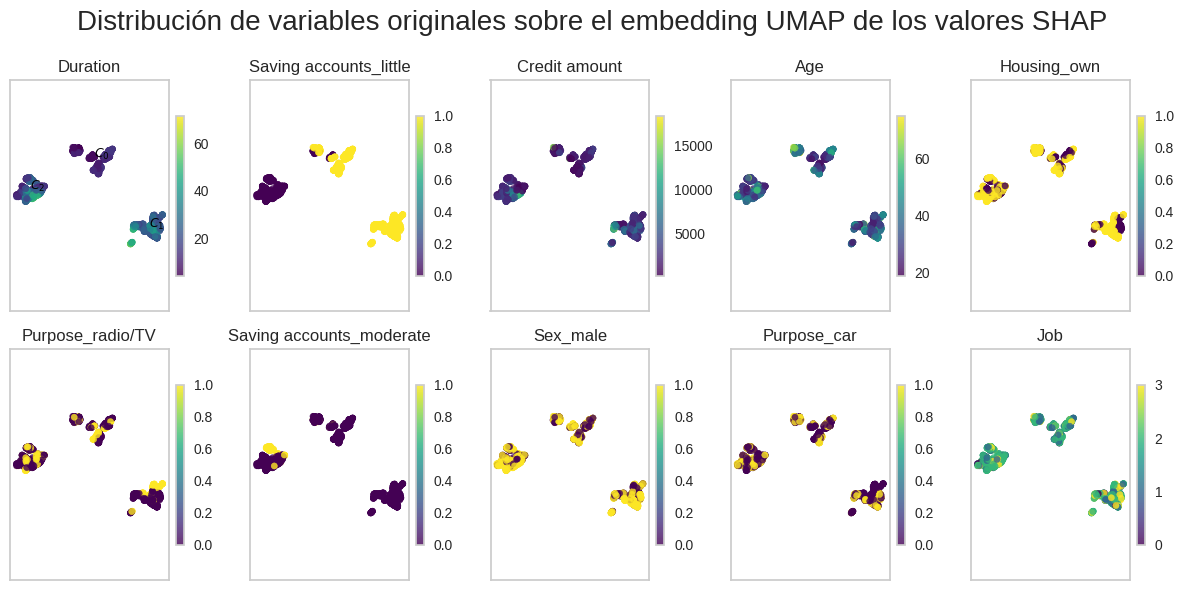

In [91]:
# SHAP embedding coloreado por valores originales

# Creamos una figura con 2 filas y 5 columnas para mostrar las 10 variables más importantes
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

# Convertimos la matriz de ejes en una lista para poder recorrerla fácilmente
axes = axes.flatten()

# Recorremos cada gráfico y cada variable importante
for ax, var in zip(axes, top_vars):

    # Dibujamos el mismo mapa UMAP-SHAP, pero coloreando los puntos
    # según el valor original de la variable correspondiente
    im = ax.scatter(
        S_2d[:, 0],      # Coordenada 1 de UMAP
        S_2d[:, 1],      # Coordenada 2 de UMAP
        c=X[var],        # Color según el valor original de la variable
        cmap="viridis",  # Escala de color: oscuro = bajo, claro = alto
        s=20,            # Tamaño de los puntos
        alpha=0.8        # Transparencia de los puntos
    )

    # Mantiene la misma proporción visual en ambos ejes
    ax.axis("equal")

    # Quitamos etiquetas de los ejes porque aquí importa la distribución visual
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Quitamos los números de los ejes para que la gráfica quede más limpia
    ax.set_xticks([])
    ax.set_yticks([])

    # Título de cada subgráfico con el nombre de la variable
    ax.set_title(var, fontsize=12)

    # Solo añadimos las etiquetas de los clusters en el primer gráfico,
    # para no repetirlas en los 10 subgráficos
    if var == top_vars[0]:

        # Recorremos los clusters encontrados por DBSCAN
        for cluster in sorted(np.unique(clusters)):

            # No etiquetamos el ruido
            if cluster == -1:
                continue

            # Calculamos el centro medio de cada cluster
            centro = S_2d[clusters == cluster].mean(axis=0)

            # Añadimos la etiqueta del cluster sobre el mapa
            ax.annotate(
                rf"$C_{{{cluster}}}$",
                (centro[0], centro[1]),
                fontsize=9,
                fontweight="bold",
                color="black"
            )

    # Añadimos una barra de color para interpretar los valores de cada variable
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Título general de la figura
fig.suptitle(
    "Distribución de variables originales sobre el embedding UMAP de los valores SHAP",
    fontsize=20
)

# Ajustamos los márgenes para que no se solapen los gráficos
fig.tight_layout()

# Mostramos la figura final
plt.show()

# **6) SKOPE RULES**

**Objetivo:**
El objetivo de esta fase es obtener reglas interpretables que permitan describir los clusters mediante variables originales del conjunto de datos. DBSCAN ya ha asignado una etiqueta de cluster a cada observación. SkopeRules no vuelve a crear los clusters. Lo que hace es aprender reglas que distingan cada cluster del resto.


**Para cada cluster se crea una variable objetivo:**

1 = pertenece al cluster actual

0 = pertenece a cualquier otro cluster

Y SkopeRules busca reglas interpretables como:

**Duration > 24 and Saving_accounts_little = 1**

In [92]:
def skoperules_models(
    X,  # DataFrame con las variables originales que se usarán para generar las reglas.
    labels,  # Etiquetas de cluster obtenidas previamente con DBSCAN.
    n_estimators: int = 100,  # Número de árboles generados internamente por SkopeRules para extraer reglas candidatas.
    recall_min: float = 0.1,  # Recall mínimo exigido a una regla para ser aceptada. 0.1 significa que debe cubrir al menos el 10% del cluster.
    max_depth: int = 3,  # Profundidad máxima de los árboles. Controla la complejidad de las reglas; con 3 se permiten reglas de hasta unas 3 condiciones.
    max_depth_duplication: int = 4,  # Profundidad usada para detectar y eliminar reglas duplicadas o muy parecidas.
    max_samples: float = 0.8,  # Proporción de observaciones usadas para entrenar cada árbol. 0.8 significa que cada árbol usa el 80% de los datos.
    random_state: int = 42  # Semilla aleatoria para que los resultados sean reproducibles.
):
    # Hacemos una copia para no modificar X original
    X_rules = X.copy()

    # Añadimos la etiqueta de cluster al DataFrame
    X_rules["cluster"] = labels

    # Diccionario donde guardaremos un modelo SkopeRules por cluster
    sr_models = {}

    # Recorremos cada cluster
    for cluster in X_rules["cluster"].value_counts().index.sort_values():

        # Xc contiene solo las variables explicativas originales
        Xc = X_rules.drop("cluster", axis=1)

        # yc vale 1 si la observación pertenece a este cluster y 0 si pertenece al resto
        yc = (X_rules["cluster"] == cluster).astype(int)

        # Creamos el modelo SkopeRules
        sr = SkopeRules(
            feature_names=Xc.columns,
            random_state=random_state,
            n_estimators=n_estimators,
            recall_min=recall_min,
            max_depth=max_depth,
            max_depth_duplication=max_depth_duplication,
            max_samples=max_samples,
            max_features=None
        )

        # Entrenamos reglas para distinguir este cluster frente al resto
        sr.fit(Xc, yc)

        # Guardamos el modelo del cluster
        sr_models[cluster] = sr

    return sr_models

In [93]:
sr_models = skoperules_models(
    X=X,
    labels=clusters
)

In [94]:
for cluster in sr_models.keys():

    print(f"Cluster {cluster}")

    if len(sr_models[cluster].rules_) == 0:
        print("N/A")

    else:
        for i, rule in enumerate(sr_models[cluster].rules_):

            # Mostramos solo la primera regla, como en el artículo
            if i == 0:

                for line in rule[0].split(" and "):
                    print(f"\t{line}")

                print(f"Precision: {rule[1][0]:.4f}")
                print(f"Recall   : {rule[1][1]:.4f}")

    print()

Cluster 0
	Duration <= 15.5
	Saving accounts_little > 0.5
Precision: 1.0000
Recall   : 0.8419

Cluster 1
	Duration > 15.5
	Saving accounts_little > 0.5
Precision: 1.0000
Recall   : 1.0000

Cluster 2
	Duration > 10.5
	Saving accounts_little <= 0.5
Precision: 0.9926
Recall   : 0.9582



# **7) Perfilado descriptivo de los clusterings**

**Objetivo:** El objetivo de esta fase es analizar las características de los clusters identificados previamente y complementar su interpretación mediante el estudio de variables relevantes y la distribución del riesgo dentro de cada grupo.

* Prepado de los datos de perfilado

In [95]:
cluster_profile = X.copy()  # Copia las variables explicativas originales ya preprocesadas.
cluster_profile['Risk'] = np.array(y)  # Añade el target para calcular tasas de riesgo.
cluster_profile['Cluster'] = clusters  # Añade el cluster asignado por DBSCAN.

print("Observaciones perfiladas por cluster:")  # Imprime un título para comprobar tamaños.
print(cluster_profile['Cluster'].value_counts().sort_index())  # Muestra cuántos casos hay en cada cluster.


Observaciones perfiladas por cluster:
Cluster
0    315
1    338
2    347
Name: count, dtype: int64


* Proporción de clientes GOOD Y BAD por cluster

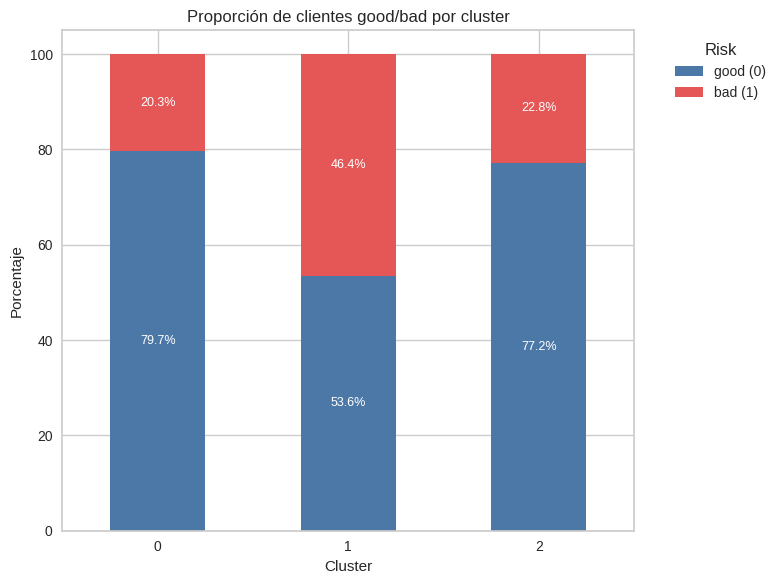

In [96]:
risk_pct = pd.crosstab(  # Calcula la distribución porcentual de Risk por cluster.
    cluster_profile['Cluster'],  # Usa los clusters como filas.
    cluster_profile['Risk'],  # Usa Risk como columnas.
    normalize='index'  # Normaliza cada fila para obtener porcentajes internos.
) * 100  # Convierte proporciones a porcentaje.

risk_pct = risk_pct.reindex(columns=[0, 1], fill_value=0)  # Asegura columnas good y bad aunque falte alguna.
risk_pct.columns = ['good (0)', 'bad (1)']  # Renombra columnas para que sean legibles.

ax = risk_pct.plot(  # Dibuja barras apiladas por cluster.
    kind='bar',  # Usa gráfico de barras.
    stacked=True,  # Apila good y bad dentro de cada cluster.
    figsize=(8, 6),  # Define el tamaño del gráfico.
    color=['#4C78A8', '#E45756']  # Asigna colores a good y bad.
)  # Cierra la llamada al gráfico.

plt.title('Proporción de clientes good/bad por cluster')  # Añade título.
plt.xlabel('Cluster')  # Añade etiqueta del eje X.
plt.ylabel('Porcentaje')  # Añade etiqueta del eje Y.
plt.xticks(rotation=0)  # Mantiene las etiquetas horizontales.

for container in ax.containers:  # Recorre las barras dibujadas.
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontsize=9)  # Añade porcentajes.

plt.legend(title='Risk', bbox_to_anchor=(1.05, 1), loc='upper left')  # Coloca la leyenda fuera del gráfico.
plt.tight_layout()  # Ajusta márgenes.
plt.show()  # Muestra el gráfico.


* Variables numéricas por cluster

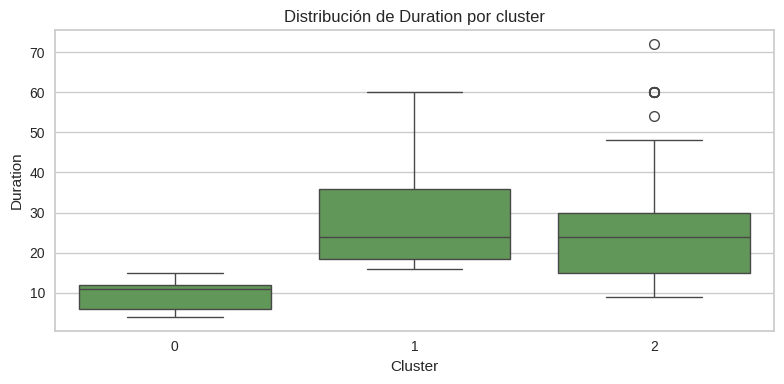

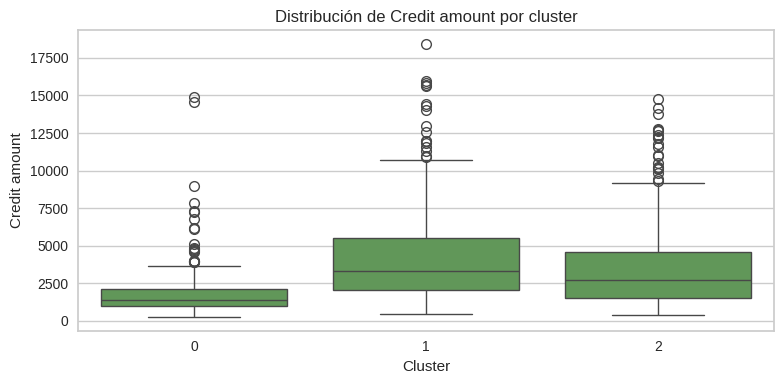

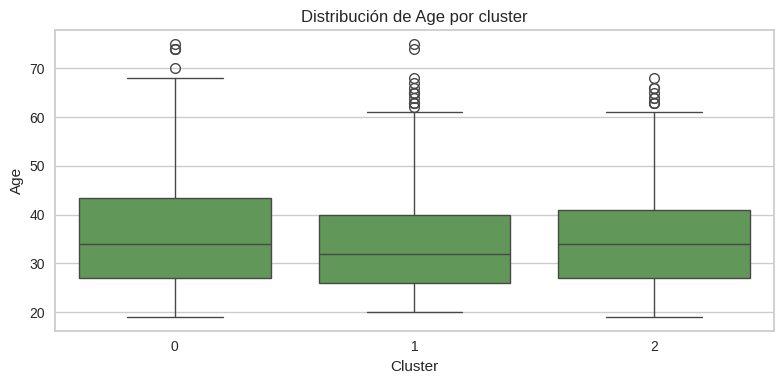

In [97]:
numeric_profile_cols = ['Duration', 'Credit amount', 'Age']  # Define variables numéricas clave del perfilado.

for col in numeric_profile_cols:  # Recorre cada variable numérica.
    plt.figure(figsize=(8, 4))  # Crea una figura nueva.
    sns.boxplot(data=cluster_profile, x='Cluster', y=col, color='#59A14F' )  # Dibuja boxplot por cluster.
    plt.title(f'Distribución de {col} por cluster')  # Añade título dinámico.
    plt.xlabel('Cluster')  # Añade etiqueta del eje X.
    plt.ylabel(col)  # Añade etiqueta del eje Y.
    plt.tight_layout()  # Ajusta márgenes.
    plt.show()  # Muestra el gráfico.

* Variables categoricas por cluster

Las variables categóricas se transformaron anteriormente con `pd.get_dummies(..., drop_first=True)`.
Esto significa que una categoría de cada variable no aparece como columna explícita, porque se usa como categoría
de referencia. Por ejemplo, si en Housing aparecen las columnas `Housing_own` y `Housing_rent`, la categoría que falta
es `Housing_free`. Para poder mostrar porcentajes completos que sumen 100% por cluster, se reconstruye esa categoría
base como: 100 - suma de las categorías visibles.

In [98]:
def category_profile_by_cluster(profile_df, prefix, reference_label):  # Define una función reutilizable para dummies.
    dummy_cols = [col for col in profile_df.columns if col.startswith(prefix)]  # Busca columnas one-hot del grupo.
    props = profile_df.groupby('Cluster')[dummy_cols].mean() * 100  # Calcula porcentaje de cada dummy por cluster.
    props[reference_label] = 100 - props.sum(axis=1)  # Reconstruye la categoría base eliminada por drop_first.
    props = props.clip(lower=0)  # Evita pequeños negativos por redondeo o inconsistencias.
    props = props.round(2)  # Redondea resultados.
    return props  # Devuelve la tabla porcentual.

def plot_stacked_profile(props, title, legend_title):  # Define una función para gráficos apilados.
    ax = props.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='tab20')  # Dibuja barras apiladas.
    plt.title(title)  # Añade título del gráfico.
    plt.xlabel('Cluster')  # Añade etiqueta del eje X.
    plt.ylabel('Porcentaje')  # Añade etiqueta del eje Y.
    plt.xticks(rotation=0)  # Mantiene etiquetas horizontales.
    plt.legend(title=legend_title, bbox_to_anchor=(1.05, 1), loc='upper left')  # Coloca leyenda fuera.
    plt.tight_layout()  # Ajusta márgenes.
    plt.show()  # Muestra el gráfico.


* Saving Accounts por cluster

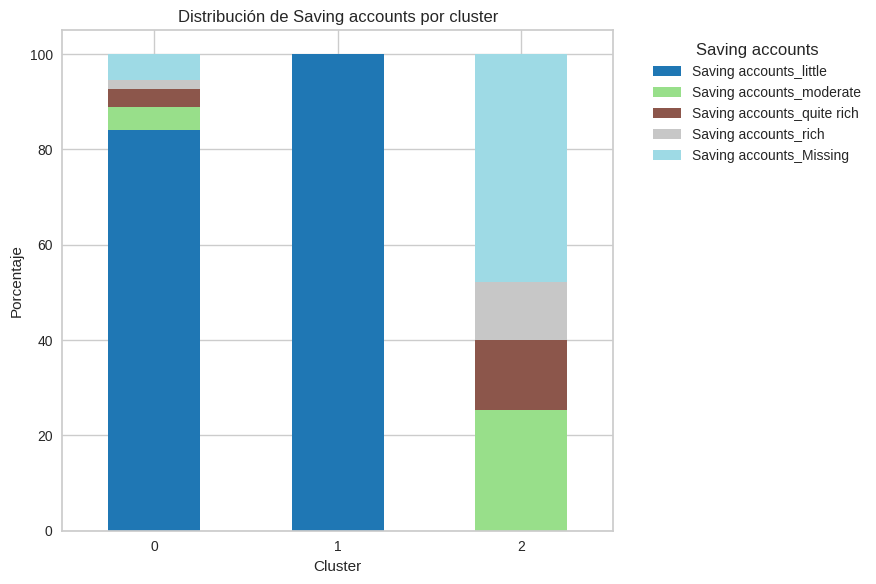

In [99]:
saving_props = category_profile_by_cluster(  # Calcula porcentajes de Saving accounts.
    cluster_profile,  # Usa la tabla perfilada sin ruido.
    'Saving accounts_',  # Usa el prefijo de columnas de ahorro.
    'Saving accounts_Missing'  # Reconstruye la categoría base de ahorro.
)  # Cierra la llamada.

plot_stacked_profile(saving_props, 'Distribución de Saving accounts por cluster', 'Saving accounts')  # Grafica ahorro.


* Housing por cluster

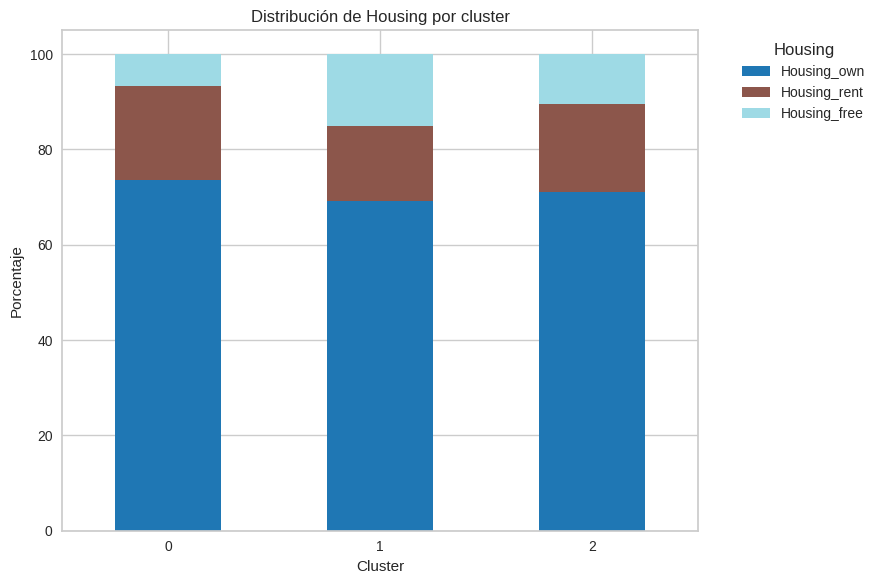

In [100]:
housing_props = category_profile_by_cluster(  # Calcula porcentajes de Housing.
    cluster_profile,  # Usa la tabla perfilada sin ruido.
    'Housing_',  # Usa el prefijo de columnas de vivienda.
    'Housing_free'  # Reconstruye la categoría base de vivienda.
)  # Cierra la llamada.
plot_stacked_profile(housing_props, 'Distribución de Housing por cluster', 'Housing')  # Grafica vivienda.

* Purpose por cluster

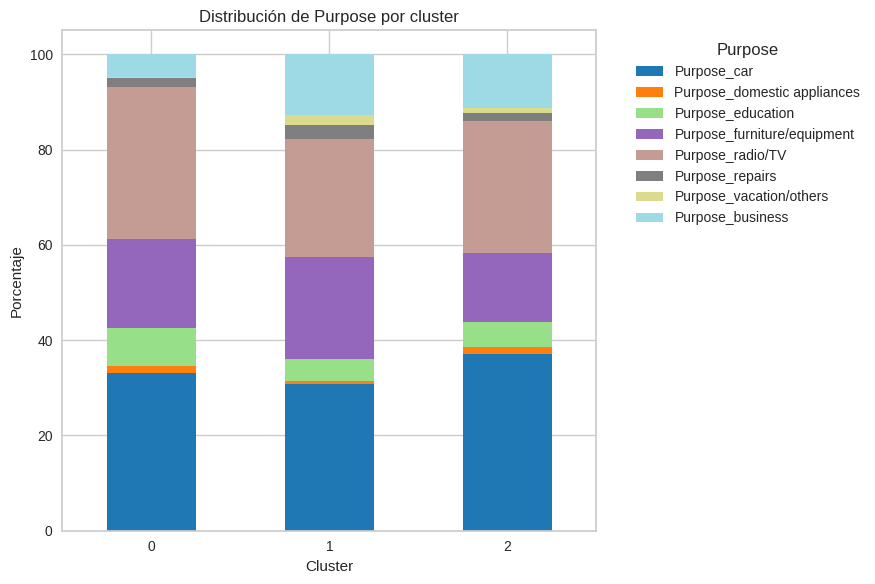

In [101]:
purpose_props = category_profile_by_cluster(  # Calcula porcentajes de Purpose.
    cluster_profile,  # Usa la tabla perfilada sin ruido.
    'Purpose_',  # Usa el prefijo de columnas de propósito.
    'Purpose_business'  # Reconstruye la categoría base de propósito.
)  # Cierra la llamada.

plot_stacked_profile(purpose_props, 'Distribución de Purpose por cluster', 'Purpose')  # Grafica propósito.